In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

In [ ]:
# 데이터 불러오기
base_url = "./data/train/"

directors = pd.read_csv(base_url + "directors.tsv", sep='\t')
genres = pd.read_csv(base_url + "genres.tsv", sep='\t')
genres_json = pd.read_json(base_url + "Ml_item2attributes.json", orient="index")
titles = pd.read_csv(base_url + "titles.tsv", sep='\t')
writers = pd.read_csv(base_url + "writers.tsv", sep='\t')
years = pd.read_csv(base_url + "years.tsv", sep='\t')
train = pd.read_csv(base_url + "train_ratings.csv")

# item별로 특정 컬럼의 값들을 리스트로 묶어주는 함수
def aggregate_to_list(df, col_name):
    return df.groupby('item')[col_name].apply(list).reset_index()

directors_agg = aggregate_to_list(directors, 'director')
writers_agg = aggregate_to_list(writers, 'writer')
genres_agg = aggregate_to_list(genres, 'genre')

total = train.merge(titles, on='item', how='left') \
             .merge(years, on='item', how='left') \
             .merge(directors_agg, on='item', how='left') \
             .merge(writers_agg, on='item', how='left') \
             .merge(genres_agg, on='item', how='left')

## 🎬 Directors 데이터 분석

In [58]:
# 결측치 확인
directors_item_missing_count = directors['item'].isnull().sum()
directors_director_missing_count = directors['director'].isnull().sum()
print(f'Directors 데이터의 item 컬럼 결측치 개수: {directors_item_missing_count}')
print(f'Directors 데이터의 director 컬럼 결측치 개수: {directors_director_missing_count}')

Directors 데이터의 item 컬럼 결측치 개수: 0
Directors 데이터의 director 컬럼 결측치 개수: 0


In [ ]:
# 영화별 감독 수 확인
director_counts = directors['item'].value_counts()
print(director_counts)

item
50912    14
1282     10
27002     8
71823     7
596       7
         ..
5504      1
2428      1
4232      1
3267      1
5105      1
Name: count, Length: 5503, dtype: int64


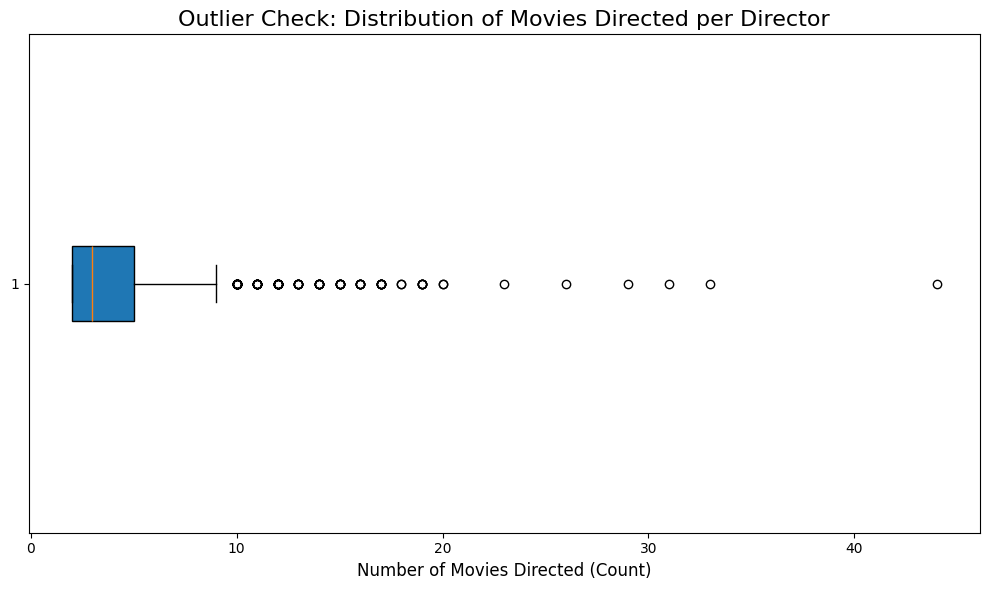

1340


In [ ]:
# 감독별 제작 영화 개수의 이상치 확인
director_counts = directors['director'].value_counts()

plt.figure(figsize=(10, 6))

plt.boxplot(director_counts.values, vert=False, patch_artist=True)

plt.title("Outlier Check: Distribution of Movies Directed per Director", fontsize=16)
plt.xlabel("Number of Movies Directed (Count)", fontsize=12)

plt.tight_layout()
plt.show()

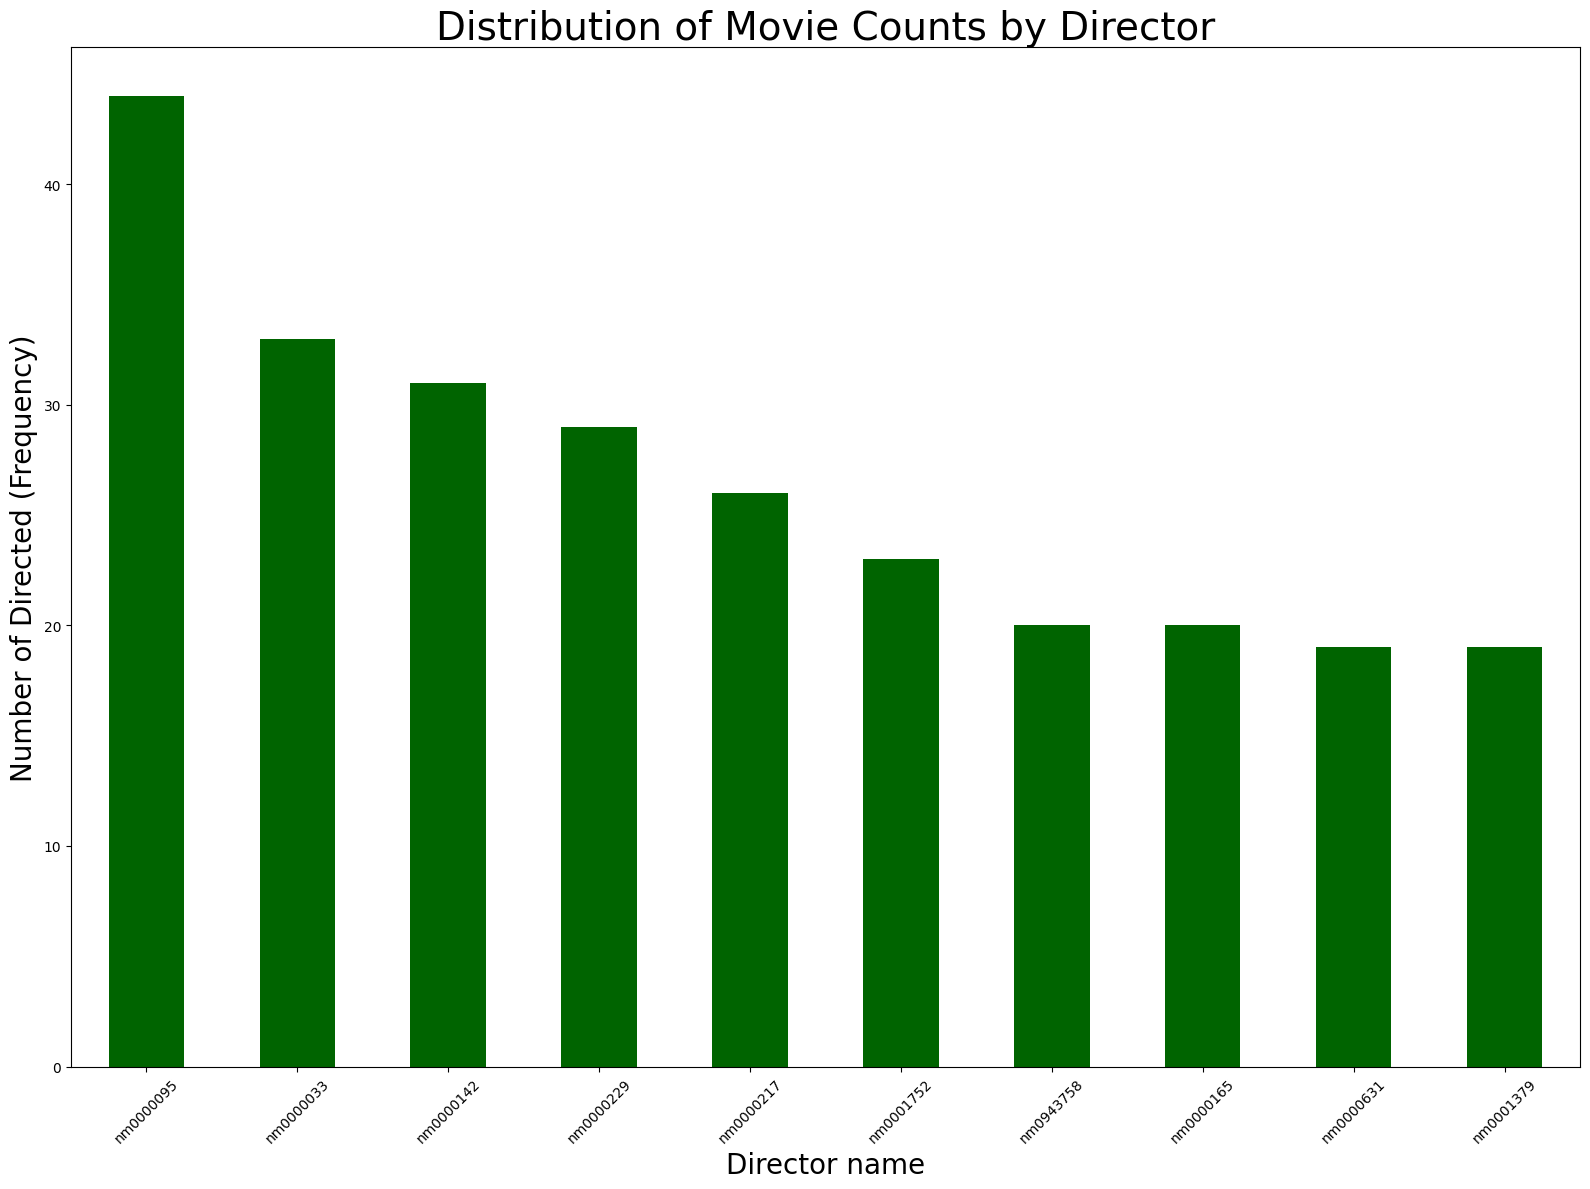

In [ ]:
# 감독별 제작 영화의 개수 분포 (상위 10개 감독)
top_n = 10
top_directors = director_counts.head(top_n)

plt.figure(figsize=(16, 12))

top_directors.plot(kind='bar', color='darkgreen')
plt.title("Distribution of Movie Counts by Director", fontsize=28)
plt.xlabel("Director name", fontsize=20)
plt.ylabel("Number of Directed (Frequency)", fontsize=20)

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

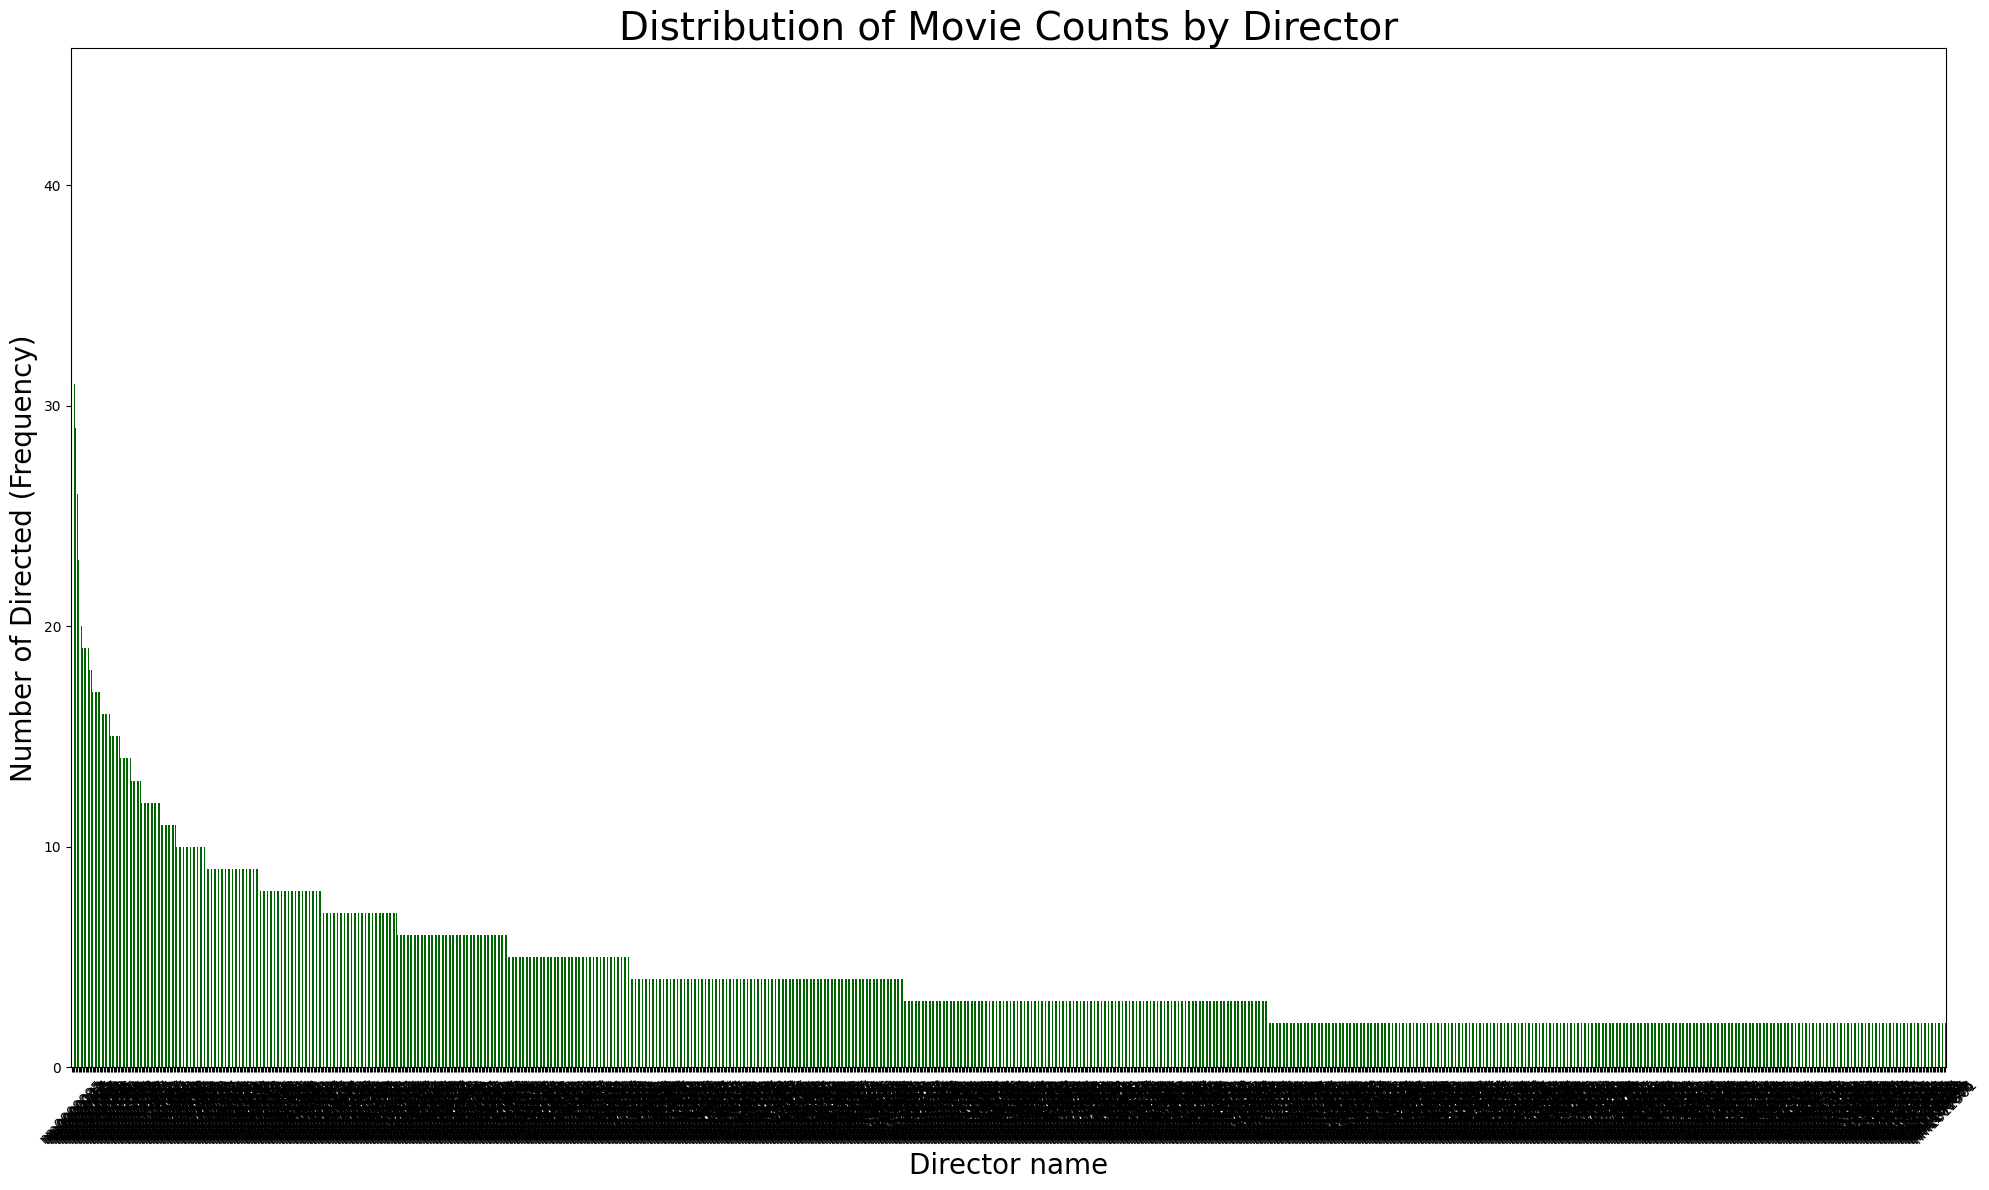

In [107]:
# 감독별 제작 영화의 개수 분포 (전체 감독)
plt.figure(figsize=(20, 12))

director_counts.plot(kind='bar', color='darkgreen')
plt.title("Distribution of Movie Counts by Director", fontsize=28)
plt.xlabel("Director name", fontsize=20)
plt.ylabel("Number of Directed (Frequency)", fontsize=20)

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [49]:
target_directors = director_counts[director_counts == 2].index
dc_2 = len(target_directors)
dc_total = len(director_counts)

ratio_percent = (dc_2 / dc_total) * 100

print(f"전체 감독 수: {dc_total}명")
print(f"영화 2개 만든 감독 수: {dc_2}명")
print(f"전체 감독 중 비율: {ratio_percent:.2f}%")

전체 감독 수: 1340명
영화 2개 만든 감독 수: 484명
전체 감독 중 비율: 36.12%


In [69]:
# 기본적인 통계치 확인
print("--- 감독별 영화 제작 개수 통계 ---")

top_director_name = director_counts.index[0]
max_movies_count = director_counts.iloc[0]
print(f'\n가장 많은 영화를 만든 감독: {top_director_name}')
print(f'제작 영화 개수: {max_movies_count}')

bot_director_name = director_counts.index[-1]
min_movies_count = director_counts.iloc[-1]
print(f'\n가장 적은 영화를 만든 감독: {bot_director_name}')
print(f'제작 영화 개수: {min_movies_count}')

avg_movies_count = director_counts.mean()
median_movies_count = director_counts.median()
std_movies_count = director_counts.std()

print(f'\n평균 영화 제작 개수: {avg_movies_count:.2f}개')
print(f'중앙값 (Median) 영화 제작 개수: {median_movies_count:.0f}개')
print(f'영화 제작 개수의 표준편차: {std_movies_count:.2f}')

--- 감독별 영화 제작 개수 통계 ---

가장 많은 영화를 만든 감독: nm0000095
제작 영화 개수: 44

가장 적은 영화를 만든 감독: nm1012501
제작 영화 개수: 2

평균 영화 제작 개수: 4.41개
중앙값 (Median) 영화 제작 개수: 3개
영화 제작 개수의 표준편차: 3.63


## 📝 Writers 데이터 분석

In [94]:
# 결측치 확인
writers_item_missing_count = writers['item'].isnull().sum()
writers_writer_missing_count = writers['writer'].isnull().sum()
print(f'Writers 데이터의 item 컬럼 결측치 개수: {writers_item_missing_count}')
print(f'Writers 데이터의 writer 컬럼 결측치 개수: {writers_writer_missing_count}')

Writers 데이터의 item 컬럼 결측치 개수: 0
Writers 데이터의 writer 컬럼 결측치 개수: 0


In [5]:
# 영화별 작가 수 확인
writer_counts = writers['item'].value_counts()
print(writer_counts)

item
1907     24
783      23
364      21
2687     21
6889     19
         ..
7941      1
7937      1
2131      1
34155     1
7936      1
Name: count, Length: 5648, dtype: int64


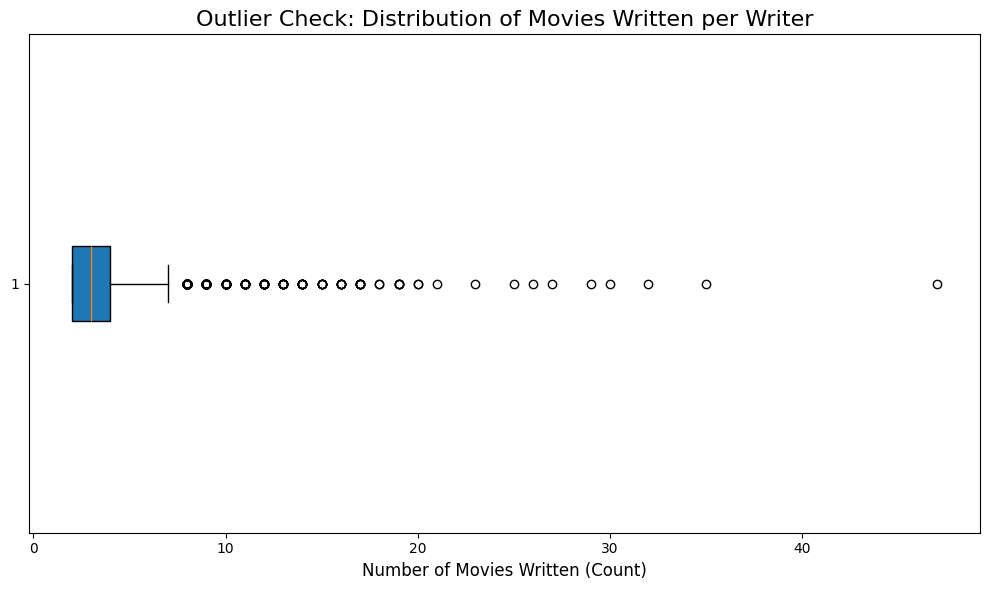

In [50]:
# 작가별 제작 영화 개수의 이상치 확인
writer_counts = writers['writer'].value_counts()

plt.figure(figsize=(10, 6))

plt.boxplot(writer_counts.values, vert=False, patch_artist=True)

plt.title("Outlier Check: Distribution of Movies Written per Writer", fontsize=16)
plt.xlabel("Number of Movies Written (Count)", fontsize=12)

plt.tight_layout()
plt.show()

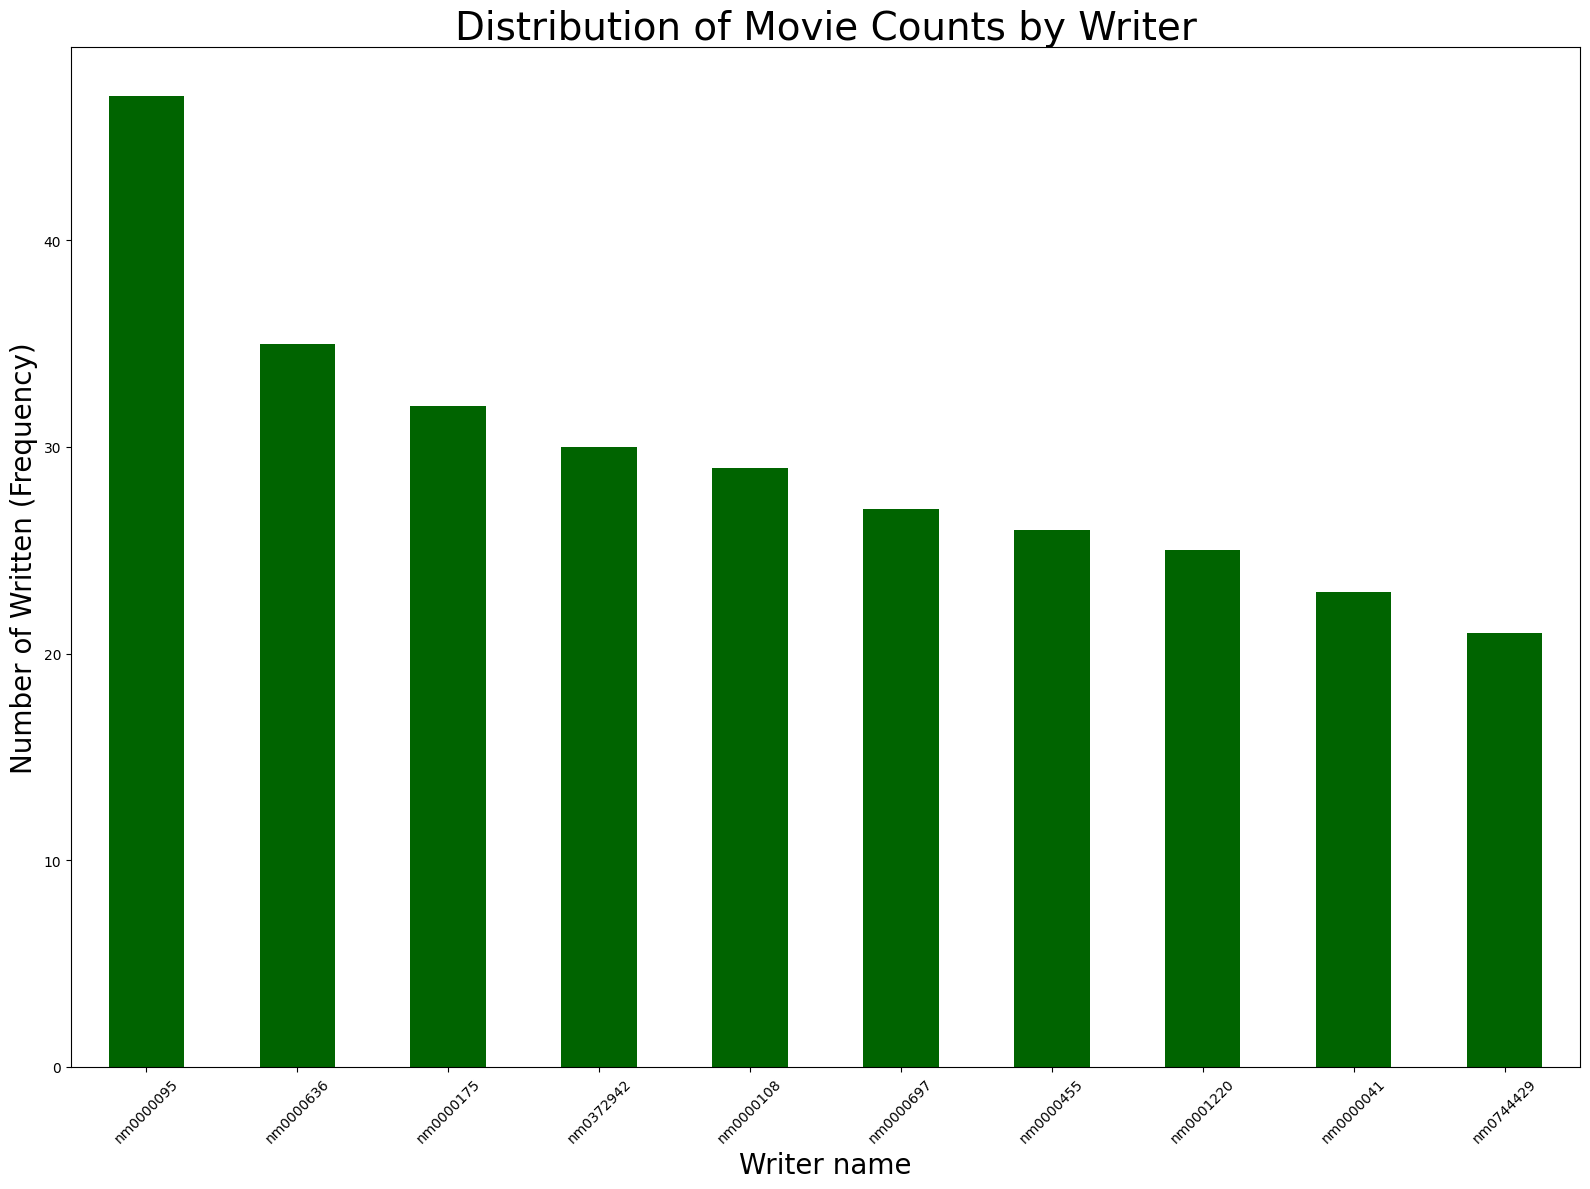

In [96]:
# 작가별 제작 영화의 개수 분포 (상위 10개 작가)
top_n = 10
top_writers = writer_counts.head(top_n)

plt.figure(figsize=(16, 12))

top_writers.plot(kind='bar', color='darkgreen')
plt.title("Distribution of Movie Counts by Writer", fontsize=28)
plt.xlabel("Writer name", fontsize=20)
plt.ylabel("Number of Written (Frequency)", fontsize=20)

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

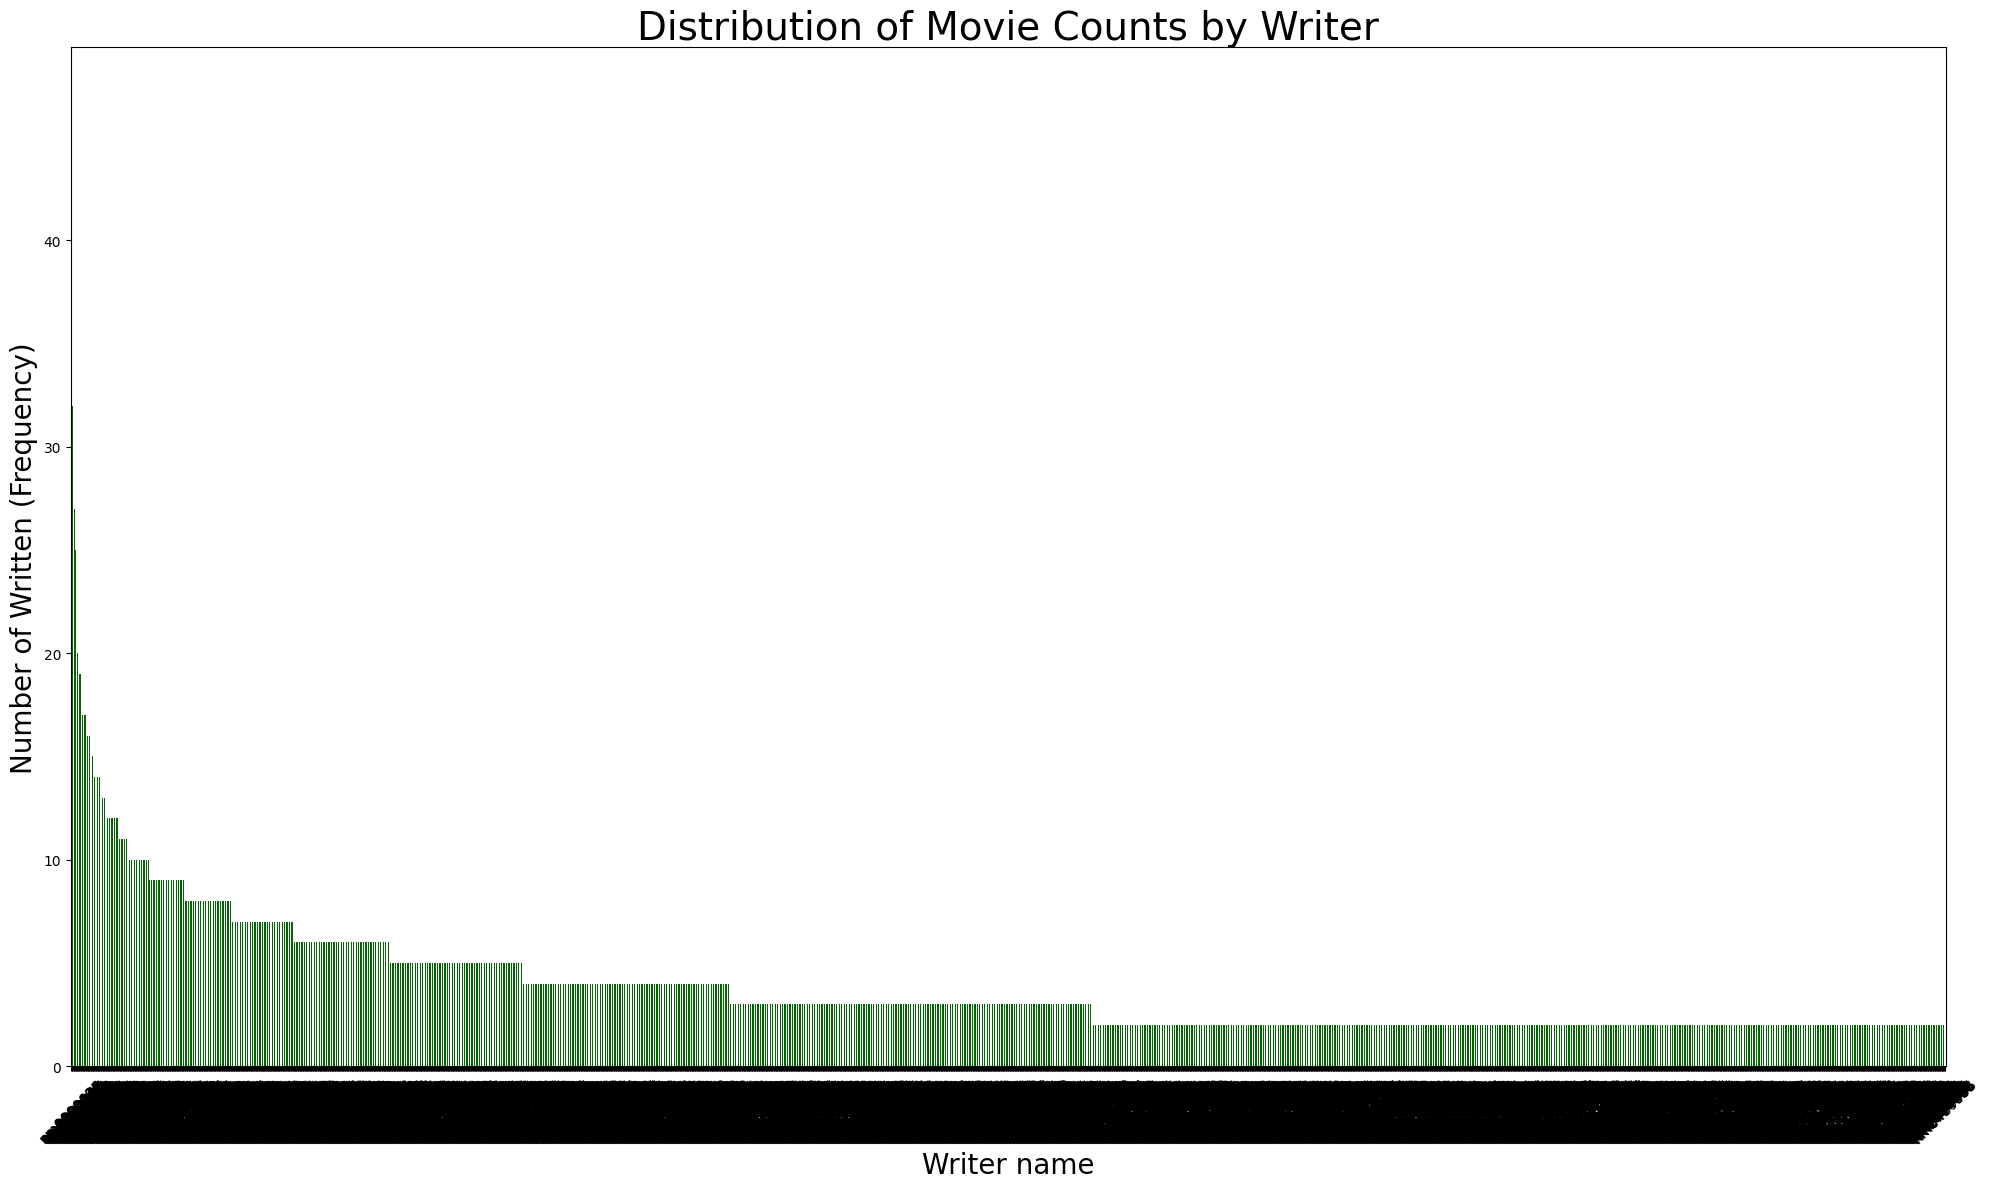

In [108]:
# 작가별 제작 영화의 개수 분포 (전체 작가)
plt.figure(figsize=(20, 12))

writer_counts.plot(kind='bar', color='darkgreen')
plt.title("Distribution of Movie Counts by Writer", fontsize=28)
plt.xlabel("Writer name", fontsize=20)
plt.ylabel("Number of Written (Frequency)", fontsize=20)

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [51]:
target_writers = writer_counts[writer_counts == 2].index
wc_2 = len(target_writers)
wc_total = len(writer_counts)

ratio_percent = (wc_2 / wc_total) * 100

print(f"전체 작가 수: {wc_total}명")
print(f"영화 2개 만든 작가 수: {wc_2}명")
print(f"전체 작가 중 비율: {ratio_percent:.2f}%")

전체 작가 수: 2989명
영화 2개 만든 작가 수: 1362명
전체 작가 중 비율: 45.57%


In [70]:
# 기본적인 통계치 확인
print("--- 작가별 영화 참여 개수 통계 ---")

top_writer_name = writer_counts.index[0]
max_movies_count = writer_counts.iloc[0]
print(f'\n가장 많은 영화에 참여한 작가: {top_writer_name}')
print(f'참여 영화 개수: {max_movies_count}')

bot_writer_name = writer_counts.index[-1]
min_movies_count = writer_counts.iloc[-1]
print(f'\n가장 적은 영화에 참여한 작가: {bot_writer_name}')
print(f'참여 영화 개수: {min_movies_count}')

avg_movies_count = writer_counts.mean()
median_movies_count = writer_counts.median()
std_movies_count = writer_counts.std()

print(f'\n평균 영화 참여 개수: {avg_movies_count:.2f}개')
print(f'중앙값 (Median) 영화 참여 개수: {median_movies_count:.0f}개')
print(f'영화 참여 개수의 표준편차: {std_movies_count:.2f}')

--- 작가별 영화 참여 개수 통계 ---

가장 많은 영화에 참여한 작가: nm0000095
참여 영화 개수: 47

가장 적은 영화에 참여한 작가: nm0489995
참여 영화 개수: 2

평균 영화 참여 개수: 3.78개
중앙값 (Median) 영화 참여 개수: 3개
영화 참여 개수의 표준편차: 2.99


## 🎥 Titles 데이터 분석

In [71]:
# 결측치 확인
titles_item_missing_count = titles['item'].isnull().sum()
titles_title_missing_count = titles['title'].isnull().sum()
print(f'Titles 데이터의 item 컬럼 결측치 개수: {titles_item_missing_count}')
print(f'Titles 데이터의 title 컬럼 결측치 개수: {titles_title_missing_count}')

Titles 데이터의 item 컬럼 결측치 개수: 0
Titles 데이터의 title 컬럼 결측치 개수: 0


In [6]:
# 영화별 제목 수 확인
title_count = titles['item'].value_counts()
print(title_count)

item
8130    1
318     1
2571    1
2959    1
296     1
       ..
1210    1
6539    1
110     1
2329    1
1       1
Name: count, Length: 6807, dtype: int64


In [80]:
# 제목 중복 확인
print("--- 제목 중복 현황 ---")

duplicate_titles = titles['title'].duplicated().sum()
print(f"중복된 제목의 총 개수 (첫 번째 제외): {duplicate_titles}개")

print(f"\n--- 중복된 제목의 정보 ---")
duplicated_rows = titles[titles['title'].duplicated(keep=False)]
print(duplicated_rows.head())

--- 제목 중복 현황 ---
중복된 제목의 총 개수 (첫 번째 제외): 1개

--- 중복된 제목의 정보 ---
       item                     title
349   34048  War of the Worlds (2005)
1926  64997  War of the Worlds (2005)


## 🗓️ Years 데이터 분석

In [16]:
# 결측치 확인
years_item_missing_count = years['item'].isnull().sum()
years_year_missing_count = years['year'].isnull().sum()
print(f'Years 데이터의 item 컬럼 결측치 개수: {years_item_missing_count}')
print(f'Years 데이터의 year 컬럼 결측치 개수: {years_year_missing_count}')

Years 데이터의 item 컬럼 결측치 개수: 0
Years 데이터의 year 컬럼 결측치 개수: 0


In [7]:
# 영화별 제작 년도 수 확인
year_counts = years['item'].value_counts()
print(year_counts)

item
109850    1
1348      1
44587     1
4768      1
8235      1
         ..
2010      1
8125      1
8275      1
2227      1
1925      1
Name: count, Length: 6799, dtype: int64


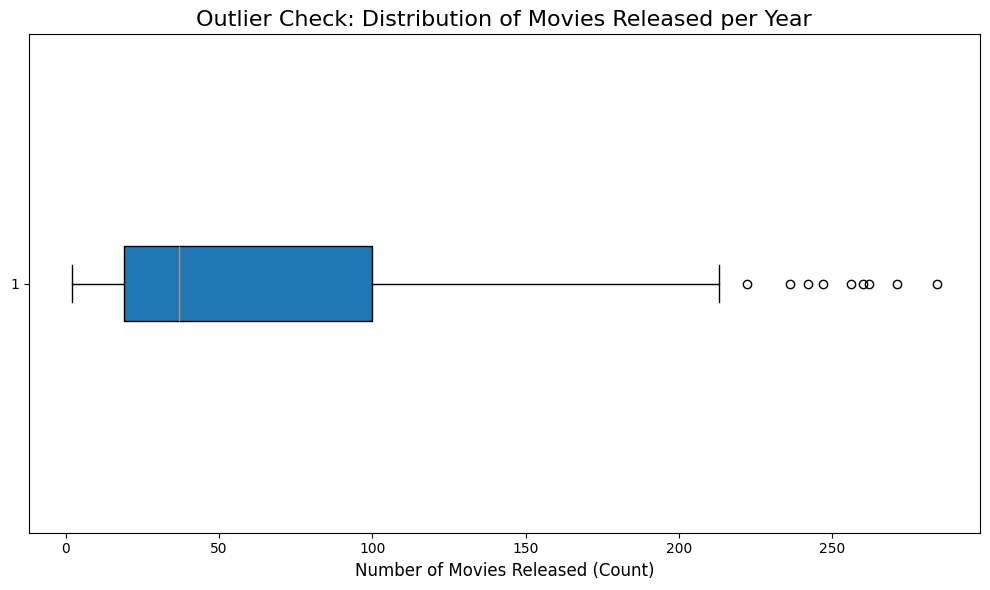

In [83]:
# 년도별 제작된 영화 개수의 이상치 확인
year_counts = years['year'].value_counts()

plt.figure(figsize=(10, 6))

plt.boxplot(year_counts.values, vert=False, patch_artist=True)

plt.title("Outlier Check: Distribution of Movies Released per Year", fontsize=16)
plt.xlabel("Number of Movies Released (Count)", fontsize=12)

plt.tight_layout()
plt.show()

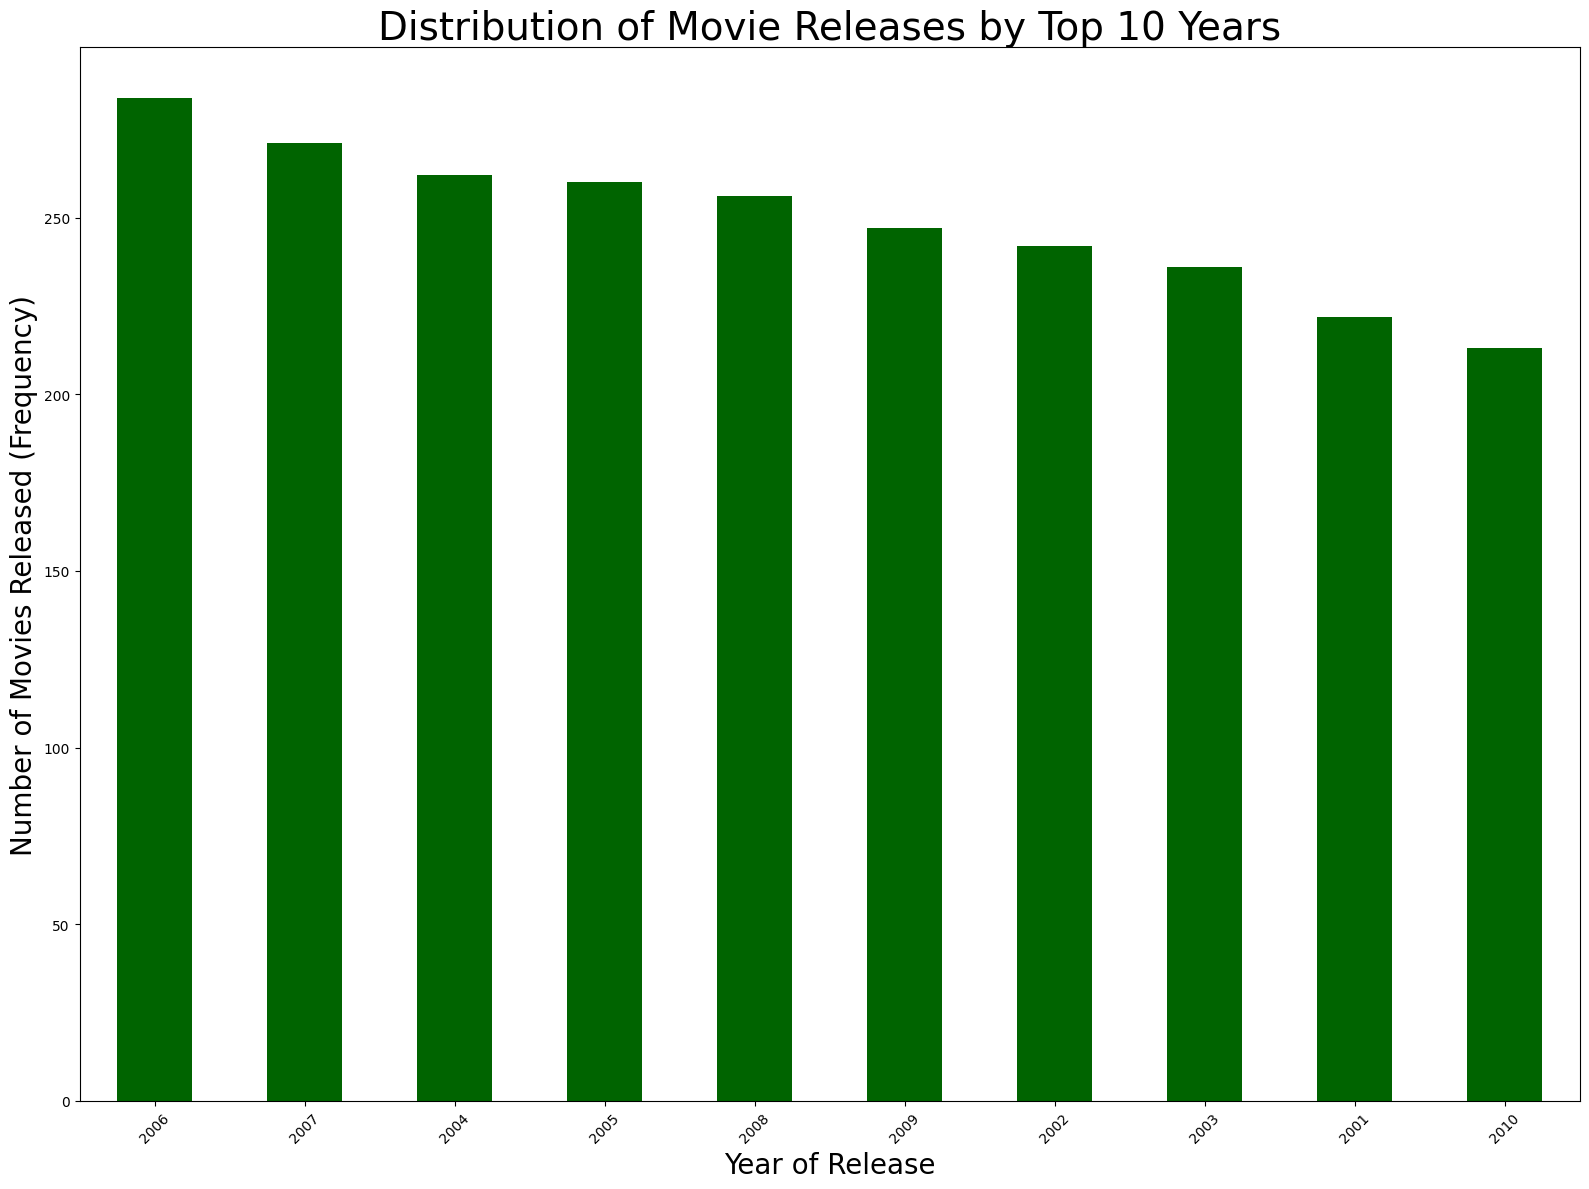

In [91]:
# 년도별 제작된 영화의 개수 분포 (상위 10개 년도)
top_n = 10
top_years = year_counts.head(top_n)

plt.figure(figsize=(16, 12))

top_years.plot(kind='bar', color='darkgreen')
plt.title(f"Distribution of Movie Releases by Top {top_n} Years", fontsize=28)
plt.xlabel("Year of Release", fontsize=20)
plt.ylabel("Number of Movies Released (Frequency)", fontsize=20)

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

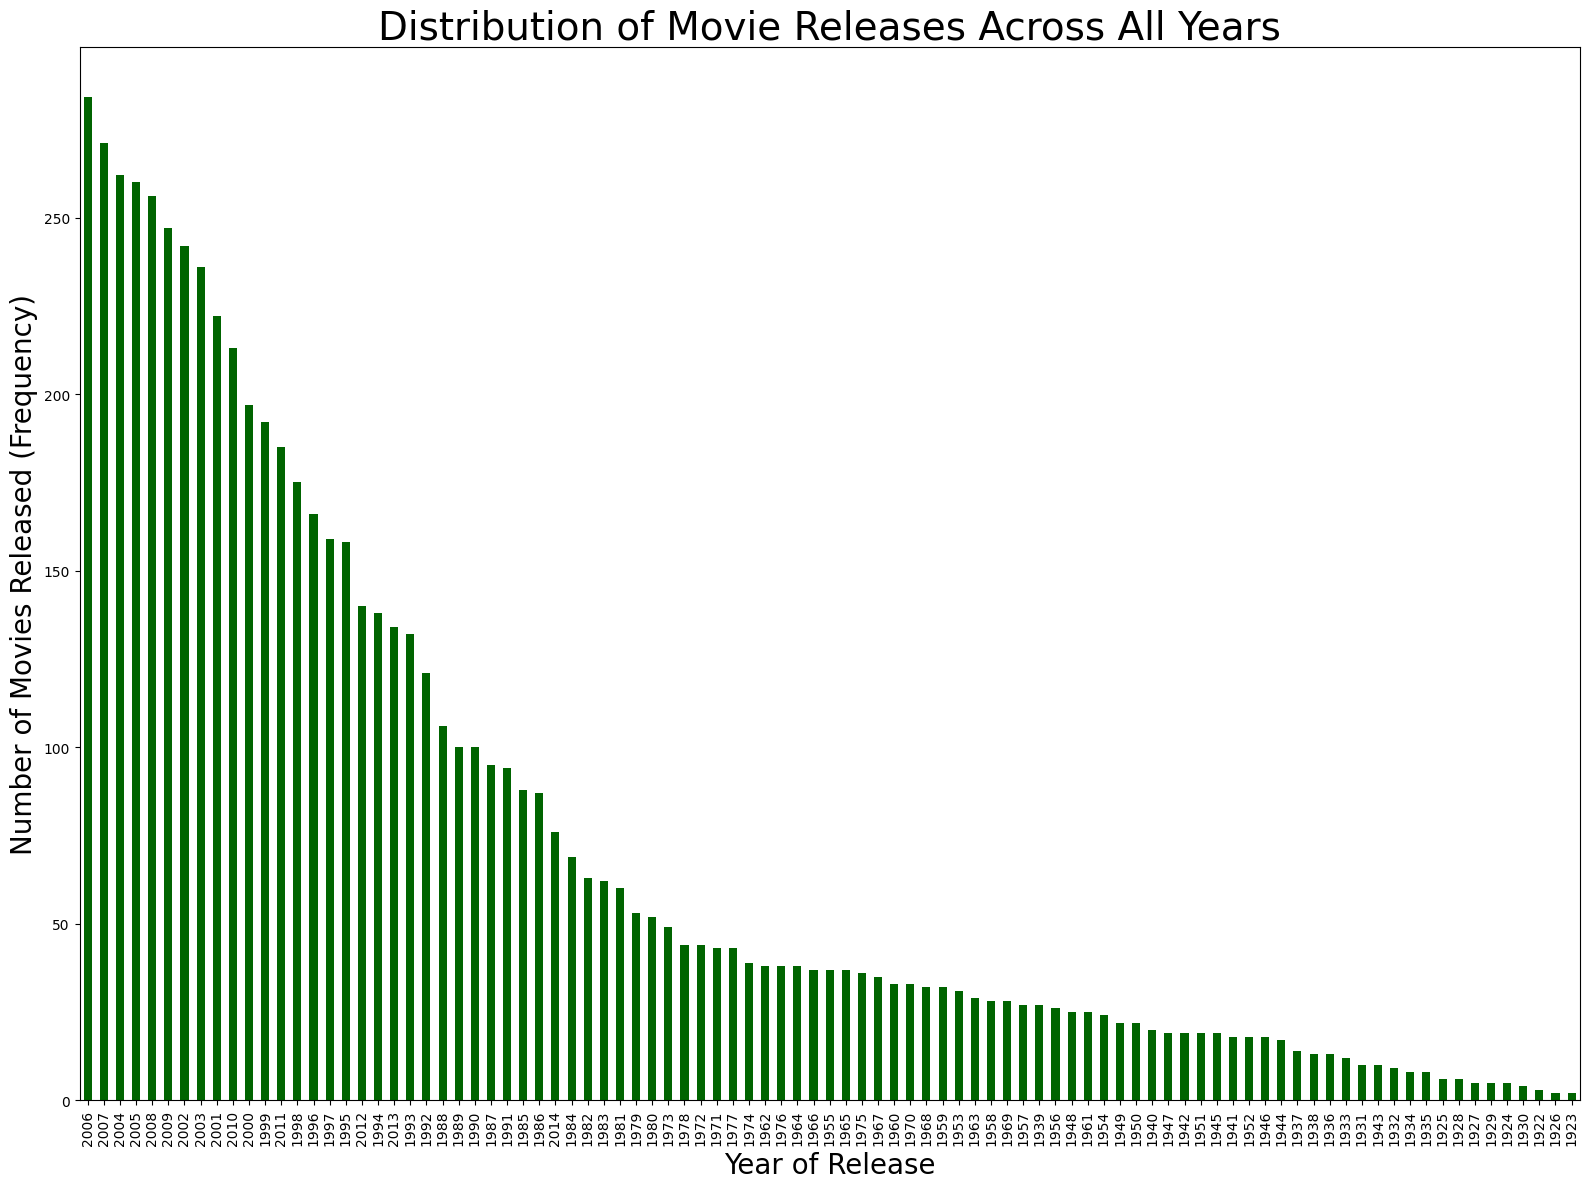

In [ ]:
# 년도별 제작된 영화의 개수 분포 (전체 년도, 개수 순)
plt.figure(figsize=(16, 12))

year_counts.plot(kind='bar', color='darkgreen')
plt.title("Distribution of Movie Releases Across All Years", fontsize=28)
plt.xlabel("Year of Release", fontsize=20)
plt.ylabel("Number of Movies Released (Frequency)", fontsize=20)

plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

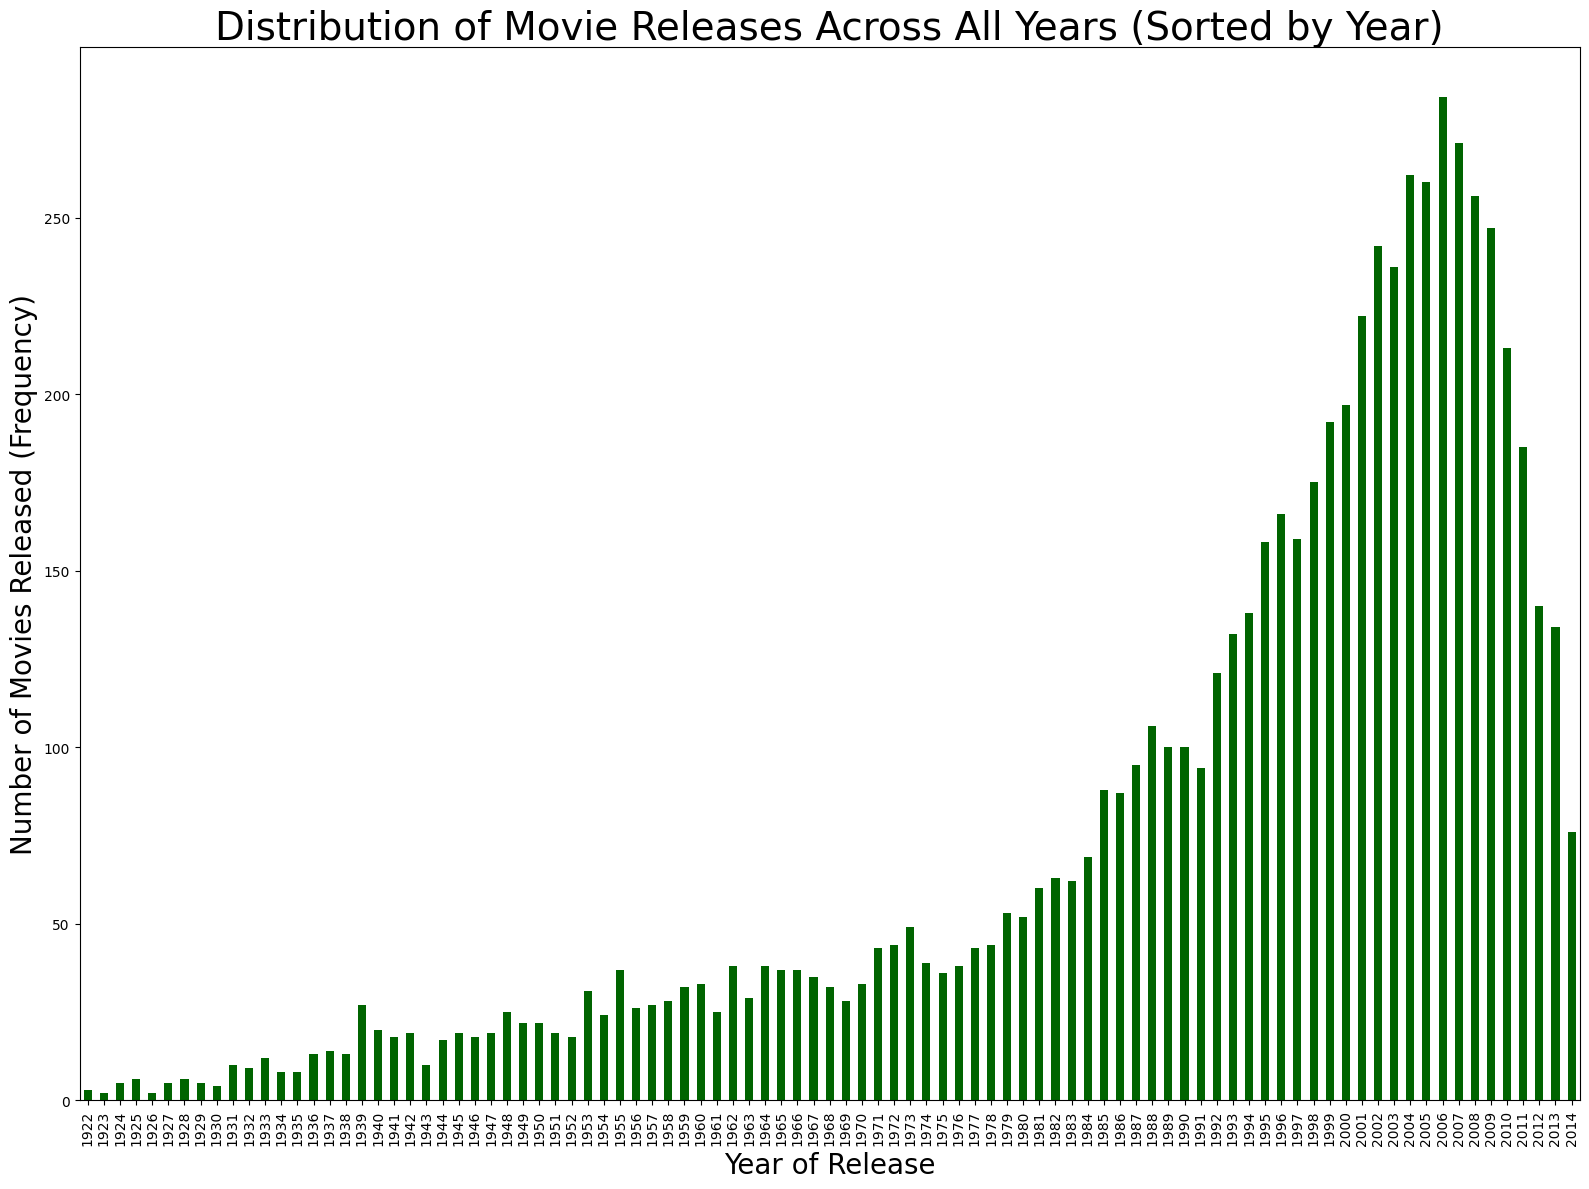

In [ ]:
# 년도별 제작된 영화의 개수 분포 (전체 년도, 년도 순)
year_counts_sorted = year_counts.sort_index(ascending=True)

plt.figure(figsize=(16, 12))

year_counts_sorted.plot(kind='bar', color='darkgreen')

plt.title("Distribution of Movie Releases Across All Years (Sorted by Year)", fontsize=28)
plt.xlabel("Year of Release", fontsize=20)
plt.ylabel("Number of Movies Released (Frequency)", fontsize=20)

plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

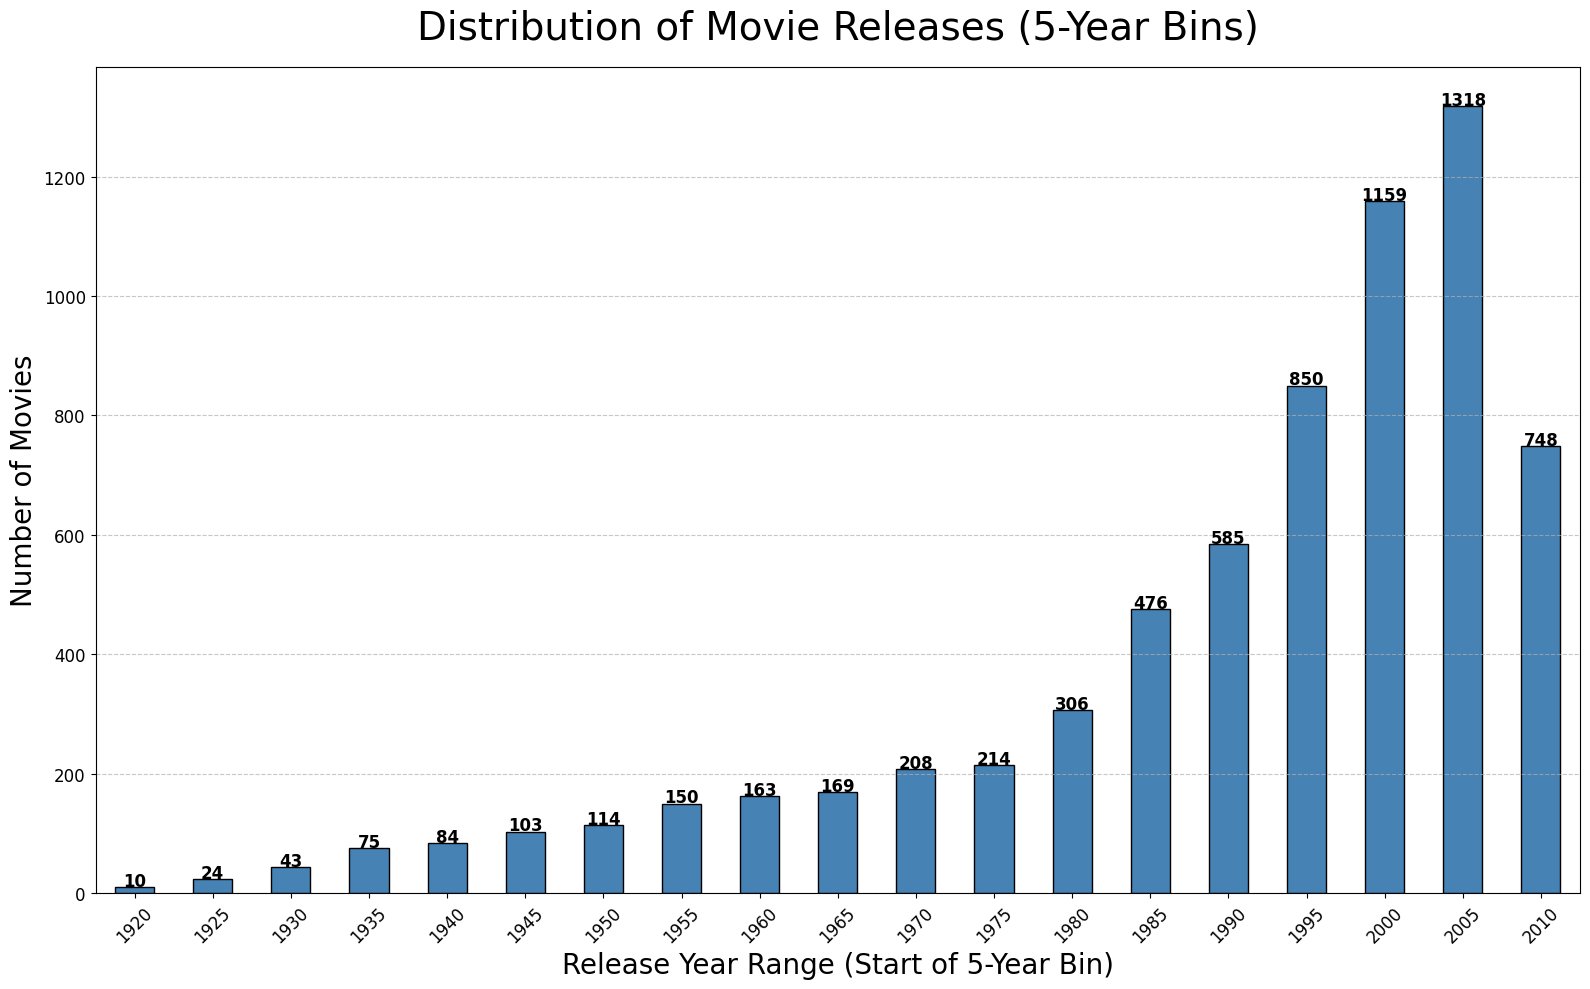

In [52]:
years['year_bin'] = (years['year'] // 5) * 5

bin_counts = years['year_bin'].value_counts().sort_index()

plt.figure(figsize=(16, 10))

bin_counts.plot(kind='bar', color='steelblue', edgecolor='black')

plt.title("Distribution of Movie Releases (5-Year Bins)", fontsize=28, pad=20)
plt.xlabel("Release Year Range (Start of 5-Year Bin)", fontsize=20)
plt.ylabel("Number of Movies", fontsize=20)

plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)

for i, v in enumerate(bin_counts):
    plt.text(i, v + 2, str(v), ha='center', fontsize=12, fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

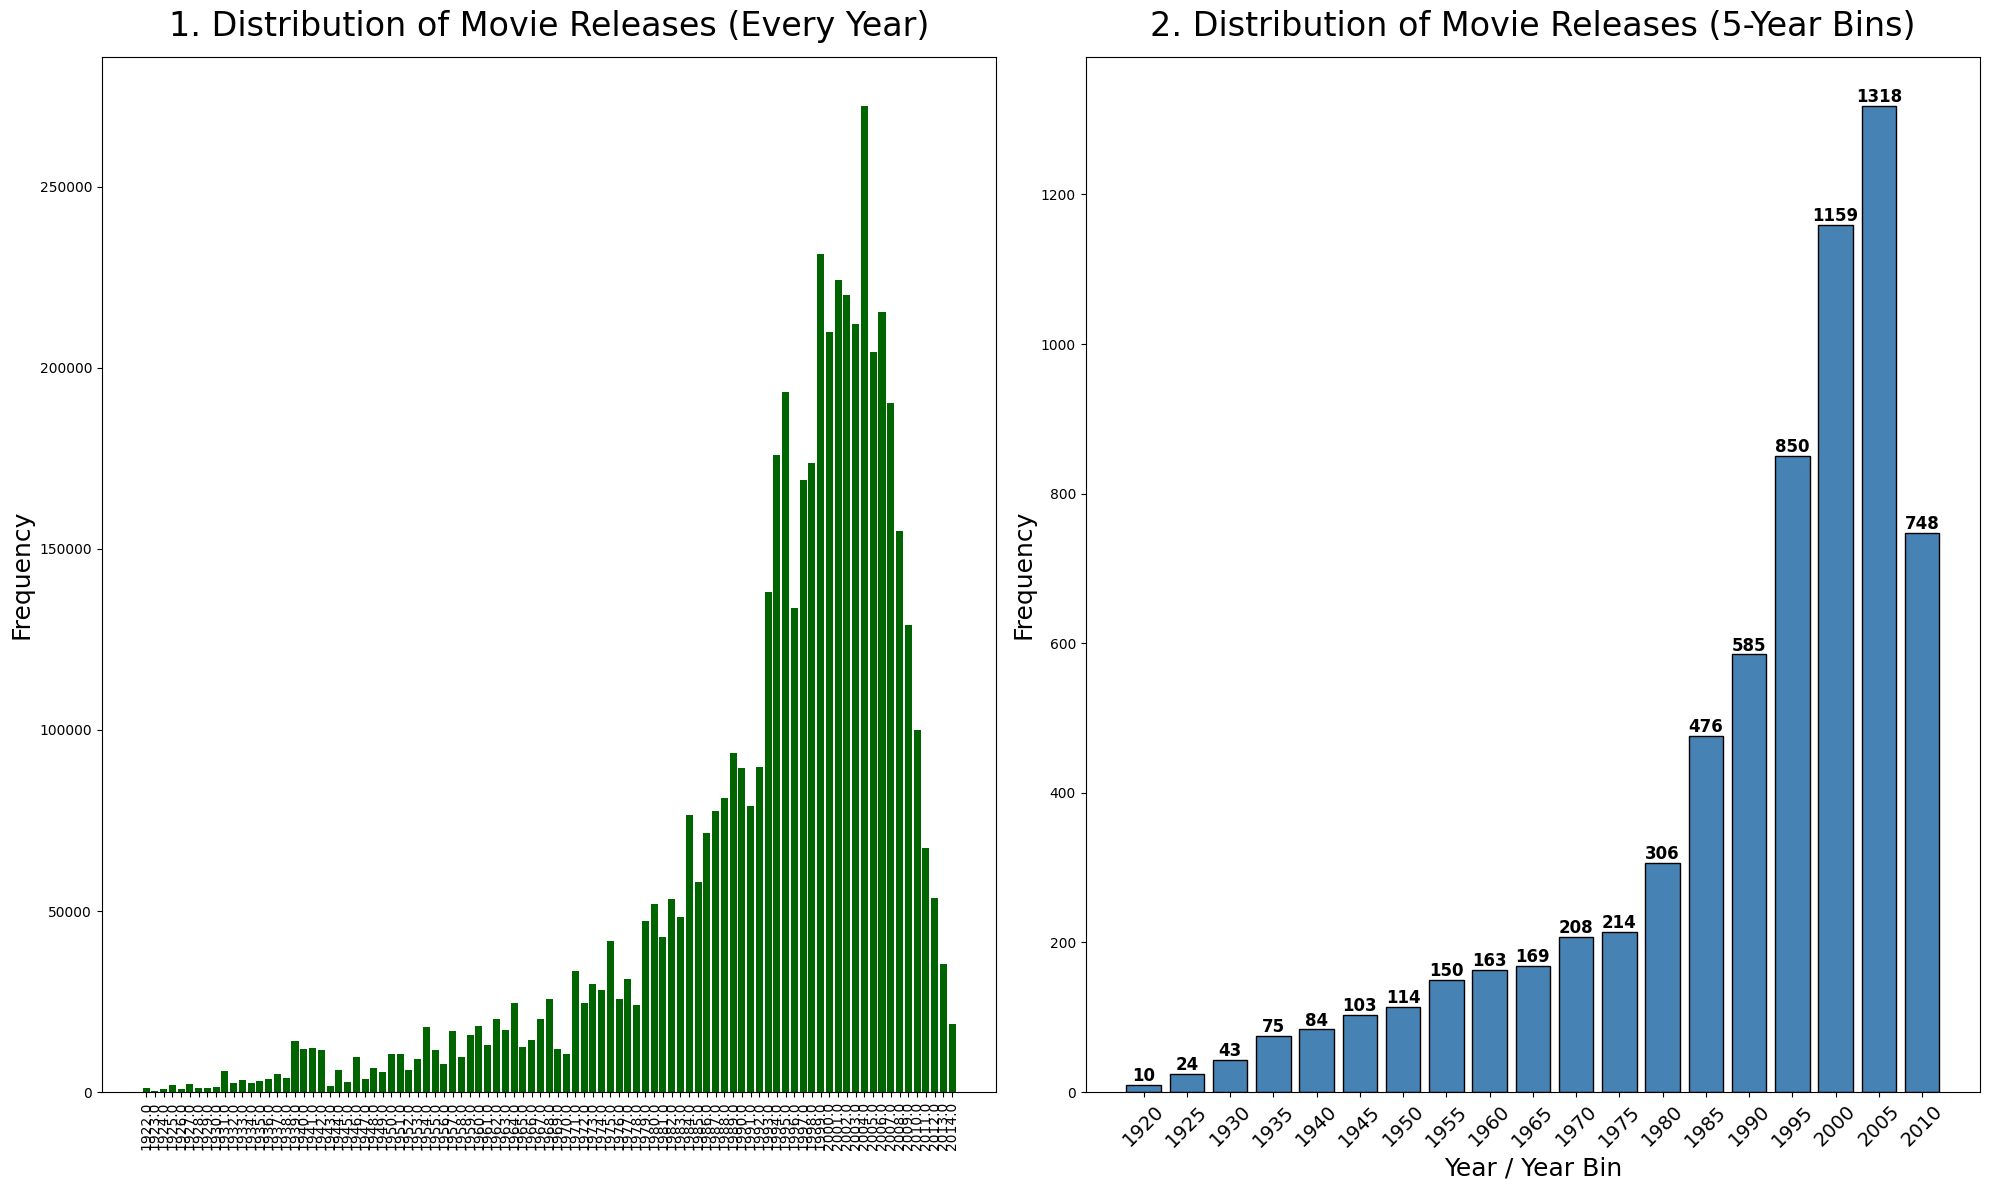

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(20, 12))

# --- 첫 번째 그래프: 전체 연도별 분포 (Original) ---
axes[0].bar(year_counts.index.astype(str), year_counts.values, color='darkgreen')
axes[0].set_title("1. Distribution of Movie Releases (Every Year)", fontsize=24, pad=15)
axes[0].set_ylabel("Frequency", fontsize=18)
axes[0].tick_params(axis='x', rotation=90, labelsize=10) # 연도가 많으므로 촘촘하게 표시

# --- 두 번째 그래프: 5년 단위 구간 분포 (Binned) ---
axes[1].bar(bin_counts.index.astype(str), bin_counts.values, color='steelblue', edgecolor='black')
axes[1].set_title("2. Distribution of Movie Releases (5-Year Bins)", fontsize=24, pad=15)
axes[1].set_xlabel("Year / Year Bin", fontsize=18)
axes[1].set_ylabel("Frequency", fontsize=18)
axes[1].tick_params(axis='x', rotation=45, labelsize=14)

# 각 막대 위에 숫자 표시 (두 번째 그래프만 가독성을 위해 추가)
for i, v in enumerate(bin_counts):
    axes[1].text(i, v + 5, str(v), ha='center', fontsize=12, fontweight='bold')

# 그래프 간 간격 조정
plt.tight_layout()

plt.show()

In [93]:
# 기본적인 통계치 확인
print("--- 년도별 제작된 영화 개수 통계 ---")

top_year = year_counts.index[0]
max_movies_count = year_counts.iloc[0]
print(f'\n가장 많은 영화가 제작된 년도: {top_year}')
print(f'제작된 영화 개수: {max_movies_count}')

bot_year = year_counts.index[-1]
min_movies_count = year_counts.iloc[-1]
print(f'\n가장 적은 영화가 제작된 년도: {bot_year}')
print(f'제작된 영화 개수: {min_movies_count}')

avg_movies_count = year_counts.mean()
median_movies_count = year_counts.median()
std_movies_count = year_counts.std()

print(f'\n평균 영화 제작 개수: {avg_movies_count:.2f}개')
print(f'중앙값 (Median) 영화 제작 개수: {median_movies_count:.0f}개')
print(f'영화 제작 개수의 표준편차: {std_movies_count:.2f}')

--- 년도별 제작된 영화 개수 통계 ---

가장 많은 영화가 제작된 년도: 2006
제작된 영화 개수: 284

가장 적은 영화가 제작된 년도: 1923
제작된 영화 개수: 2

평균 영화 제작 개수: 73.11개
중앙값 (Median) 영화 제작 개수: 37개
영화 제작 개수의 표준편차: 78.50


## 🎭 Genres 데이터 분석

In [131]:
# 결측치 확인
genres_item_missing_count = genres['item'].isnull().sum()
genres_genre_missing_count = genres['genre'].isnull().sum()
print(f'Genres 데이터의 item 컬럼 결측치 개수: {genres_item_missing_count}')
print(f'Genres 데이터의 genre 컬럼 결측치 개수: {genres_genre_missing_count}')

Genres 데이터의 item 컬럼 결측치 개수: 0
Genres 데이터의 genre 컬럼 결측치 개수: 0


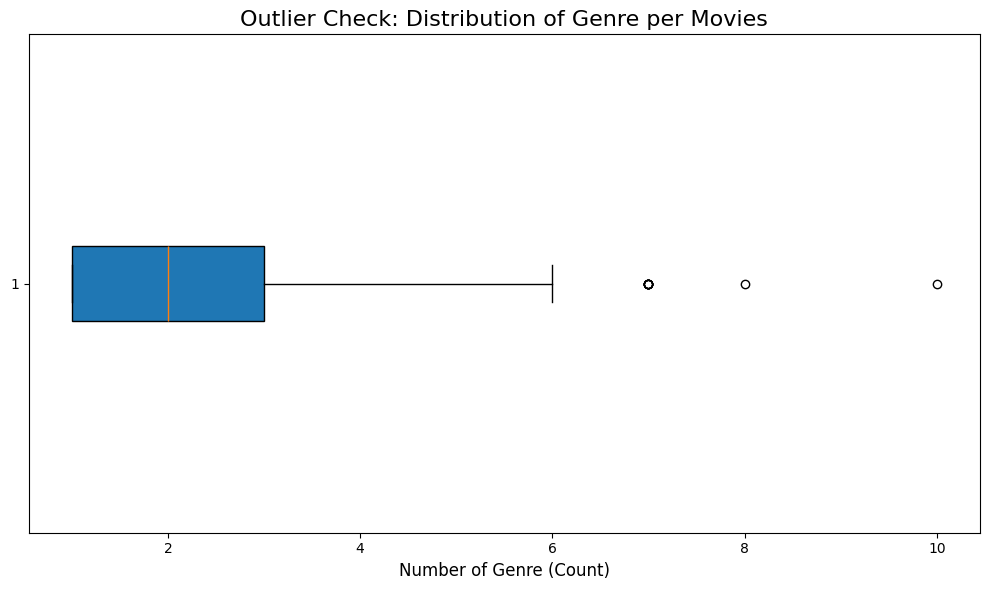

In [132]:
# 영화별 장르 개수의 이상치 확인
genre_counts = genres['item'].value_counts()

plt.figure(figsize=(10, 6))

plt.boxplot(genre_counts.values, vert=False, patch_artist=True)

plt.title("Outlier Check: Distribution of Genre per Movies", fontsize=16)
plt.xlabel("Number of Genre (Count)", fontsize=12)

plt.tight_layout()
plt.show()

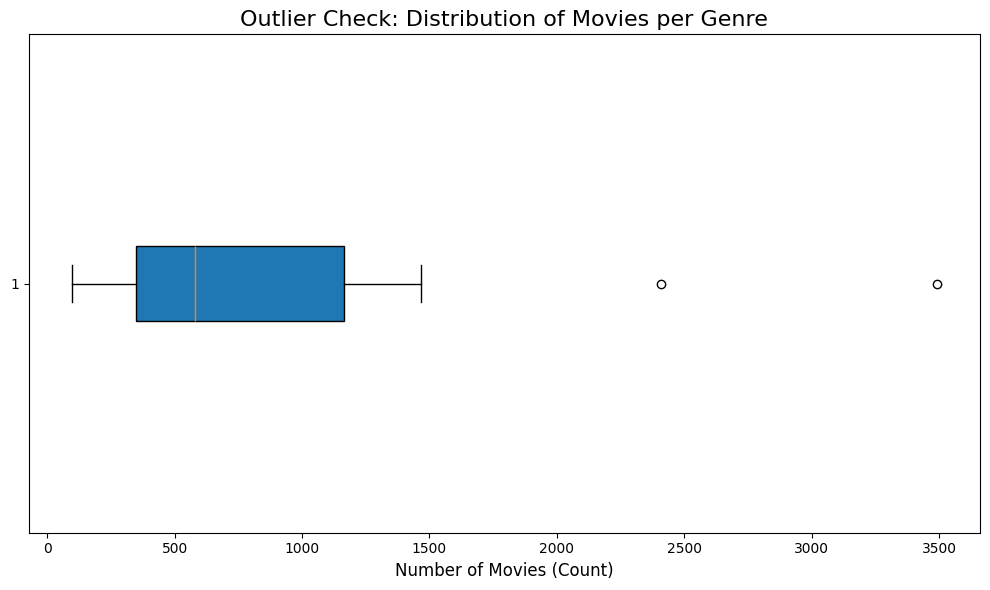

In [133]:
# 장르별 영화 개수의 이상치 확인
movie_counts = genres['genre'].value_counts()

plt.figure(figsize=(10, 6))

plt.boxplot(movie_counts.values, vert=False, patch_artist=True)

plt.title("Outlier Check: Distribution of Movies per Genre", fontsize=16)
plt.xlabel("Number of Movies (Count)", fontsize=12)

plt.tight_layout()
plt.show()

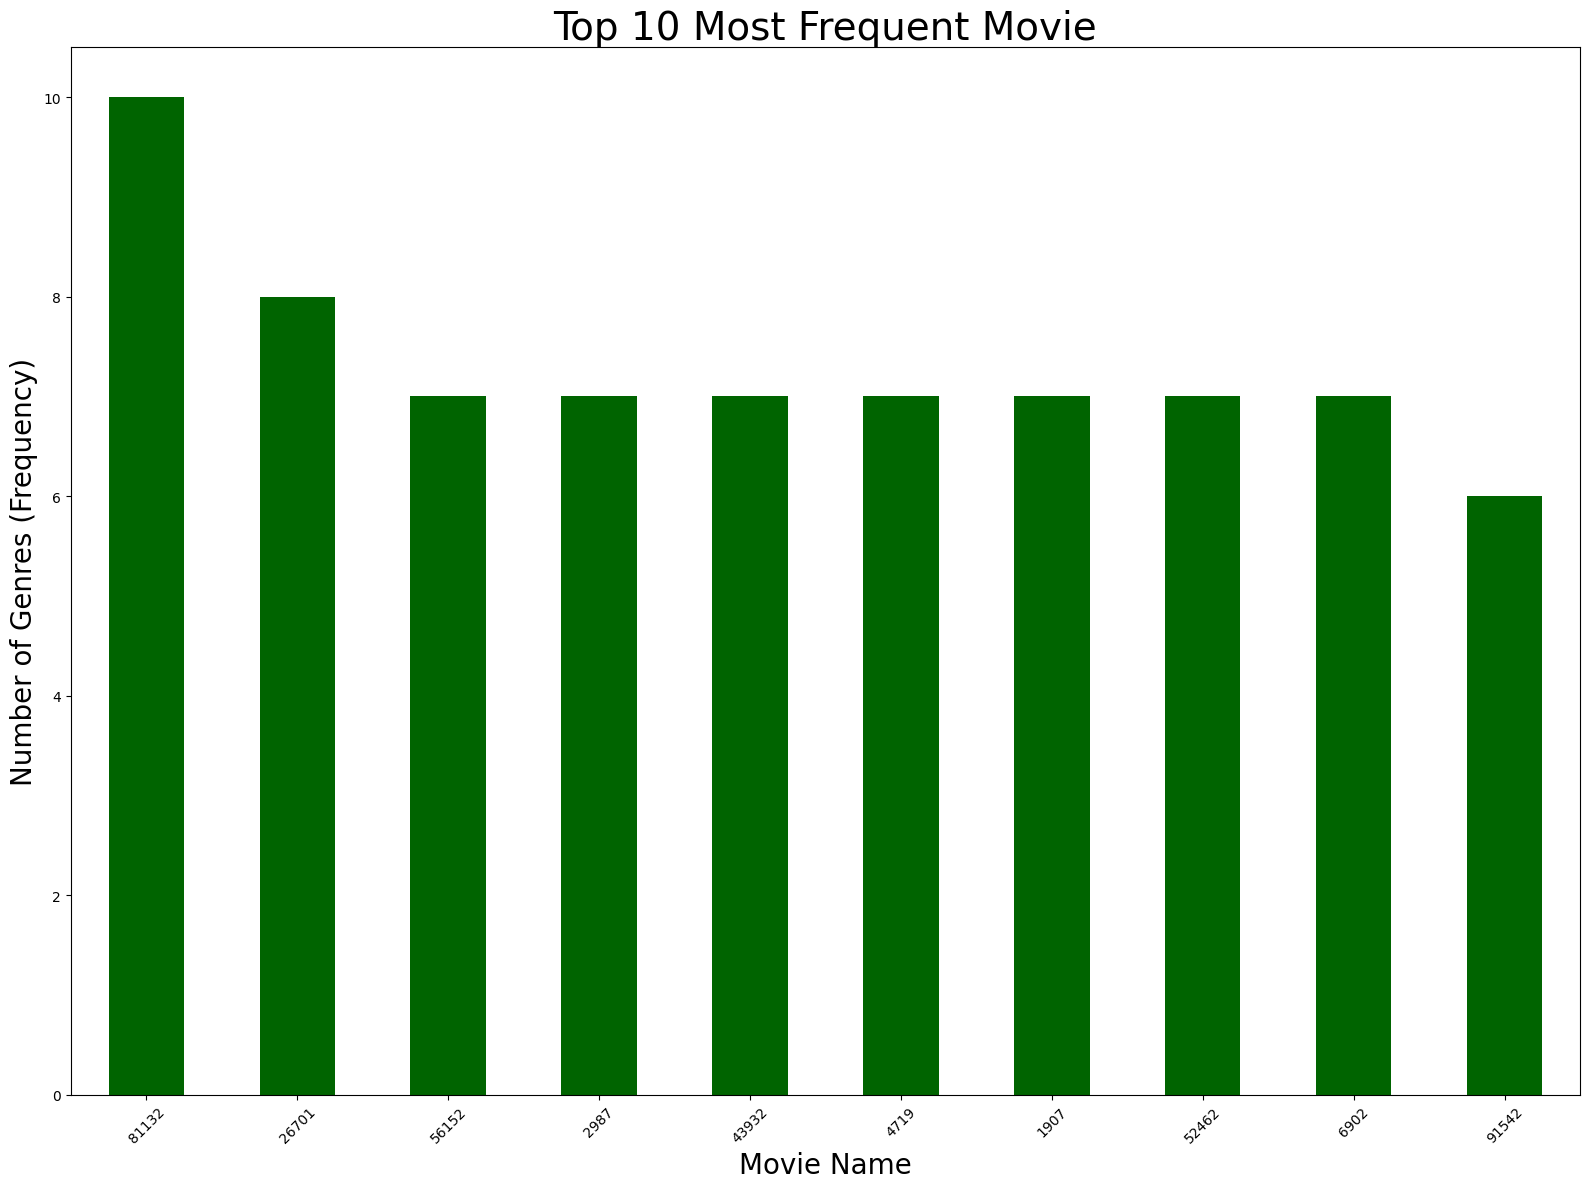

In [134]:
# 영화별 장르 개수 분포 (상위 10개 영화)
top_n = 10
top_genre = genre_counts.head(top_n)

plt.figure(figsize=(16, 12))

top_genre.plot(kind='bar', color='darkgreen')
plt.title(f"Top {top_n} Most Frequent Movie", fontsize=28)
plt.xlabel("Movie Name", fontsize=20)
plt.ylabel("Number of Genres (Frequency)", fontsize=20)

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

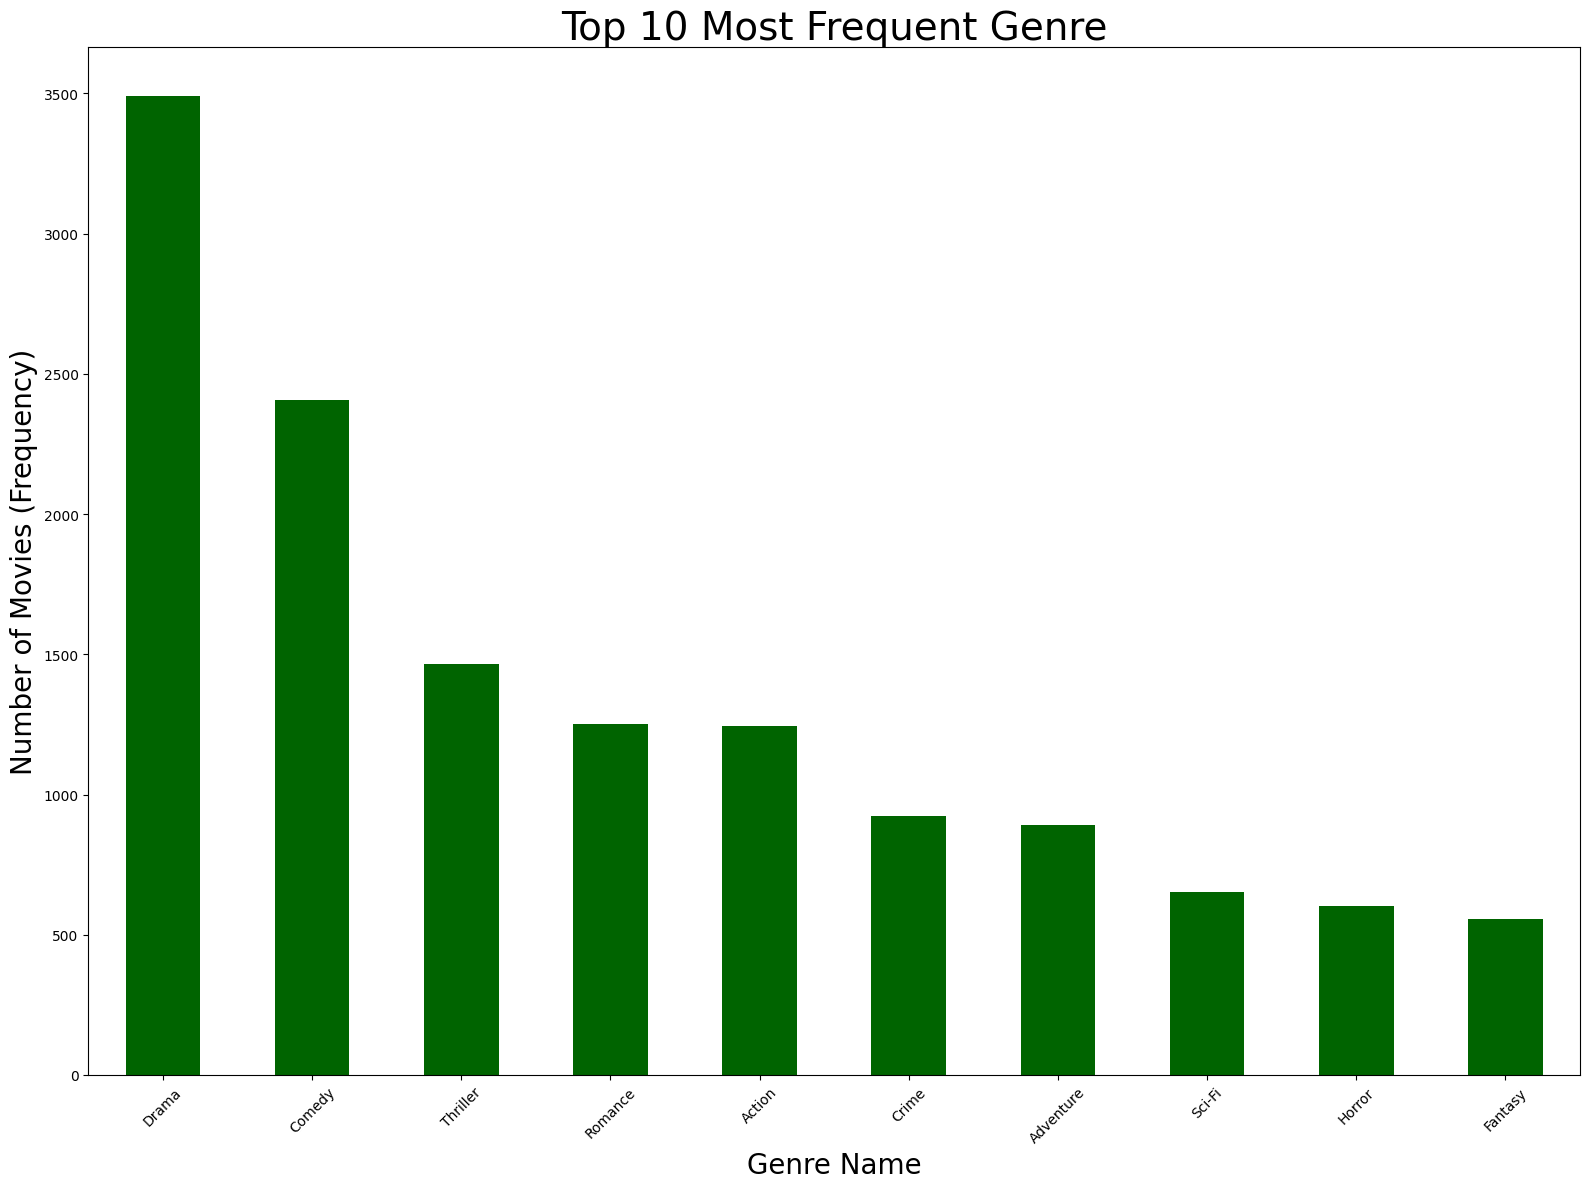

In [135]:
# 장르별 영화 개수 분포 (상위 10개 장르)
top_n = 10
top_movie = movie_counts.head(top_n)

plt.figure(figsize=(16, 12))

top_movie.plot(kind='bar', color='darkgreen')
plt.title(f"Top {top_n} Most Frequent Genre", fontsize=28)
plt.xlabel("Genre Name", fontsize=20)
plt.ylabel("Number of Movies (Frequency)", fontsize=20)

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

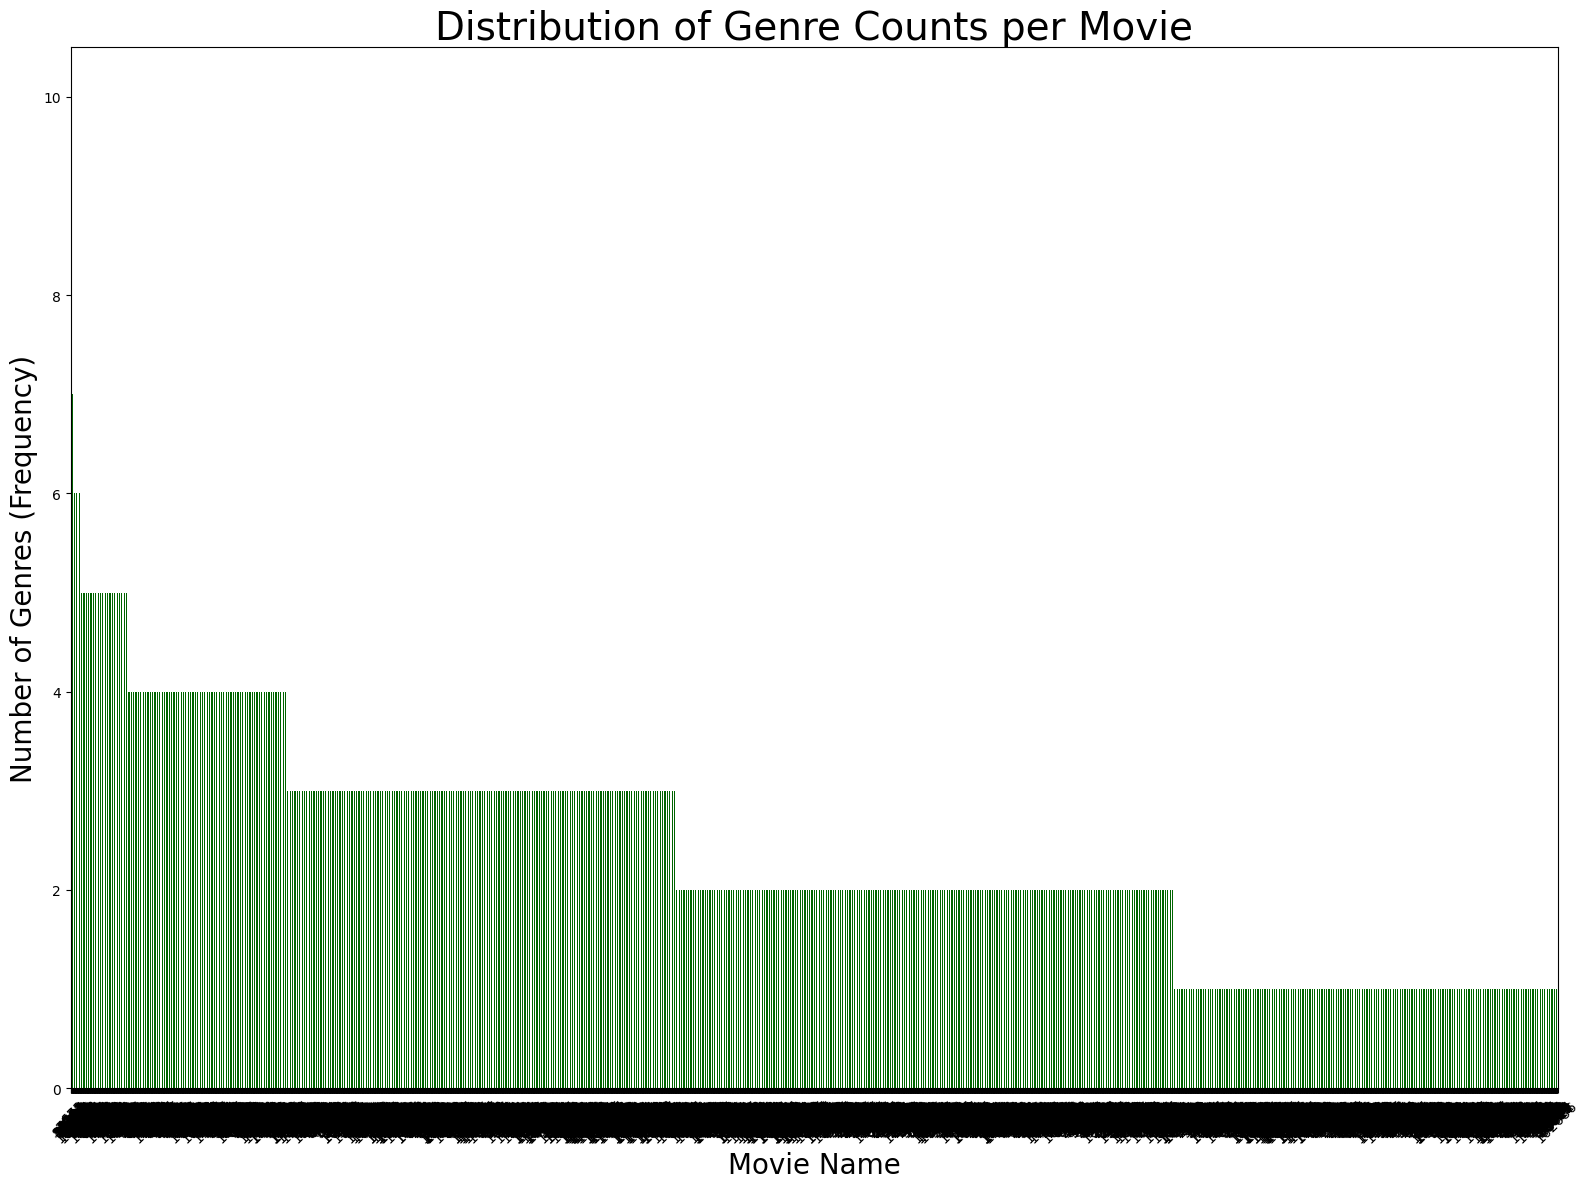

In [136]:
# 영화별 장르 개수 분포 (전체 영화)
plt.figure(figsize=(16, 12))

genre_counts.plot(kind='bar', color='darkgreen')
plt.title("Distribution of Genre Counts per Movie", fontsize=28)
plt.xlabel("Movie Name", fontsize=20)
plt.ylabel("Number of Genres (Frequency)", fontsize=20)

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

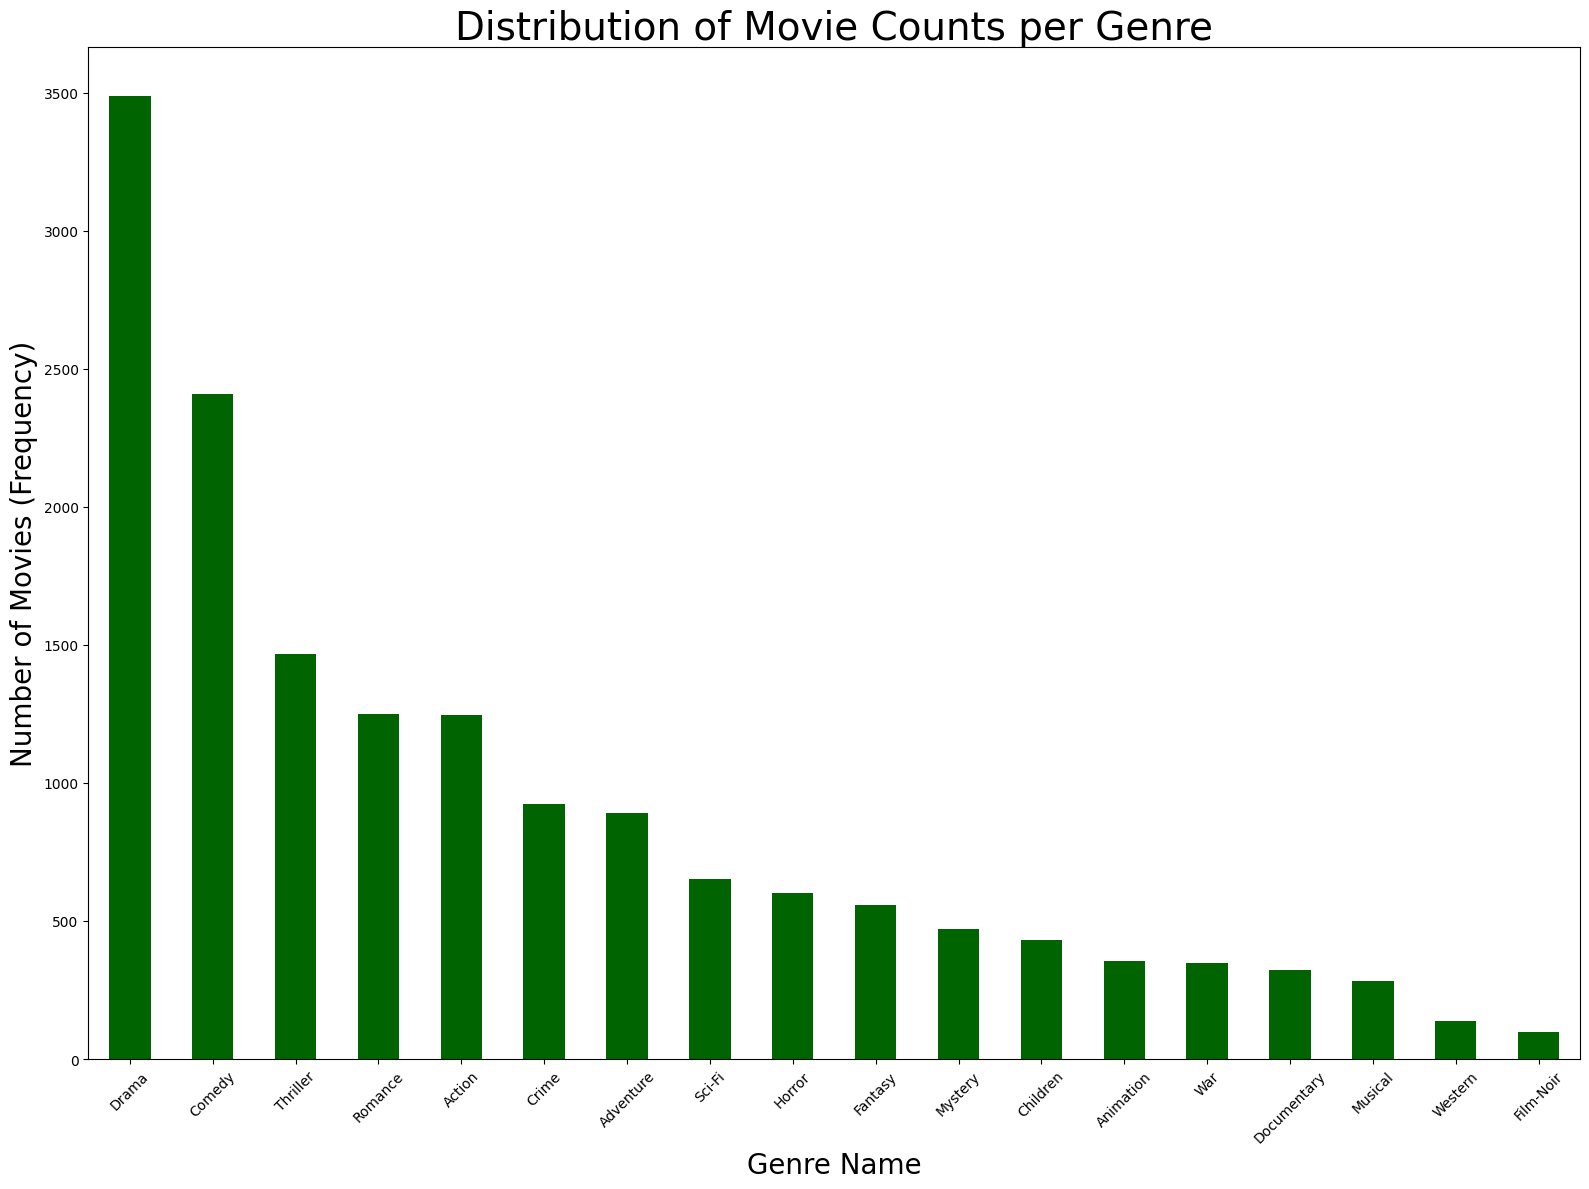

In [137]:
# 장르별 영화 개수 분포 (전체 장르)
plt.figure(figsize=(16, 12))

movie_counts.plot(kind='bar', color='darkgreen')
plt.title("Distribution of Movie Counts per Genre", fontsize=28)
plt.xlabel("Genre Name", fontsize=20)
plt.ylabel("Number of Movies (Frequency)", fontsize=20)

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [141]:
# 기본적인 통계치 확인
print("--- 장르별 영화 개수 통계 ---")

top_movie = movie_counts.index[0]
max_movies_count = movie_counts.iloc[0]
print(f'\n가장 많은 영화를 가진 장르: {top_movie}')
print(f'영화 개수: {max_movies_count}')

bot_movie = movie_counts.index[-1]
min_movies_count = movie_counts.iloc[-1]
print(f'\n가장 적은 영화를 가진 장르: {bot_movie}')
print(f'영화 개수: {min_movies_count}')

avg_movies_count = movie_counts.mean()
median_movies_count = movie_counts.median()
std_movies_count = movie_counts.std()

print(f'\n장르별 평균 영화 개수: {avg_movies_count:.2f}개')
print(f'중앙값 (Median) 영화 개수: {median_movies_count:.0f}개')
print(f'장르별 영화 개수의 표준편차: {std_movies_count:.2f}')

--- 장르별 영화 개수 통계 ---

가장 많은 영화를 가진 장르: Drama
영화 개수: 3490

가장 적은 영화를 가진 장르: Film-Noir
영화 개수: 97

장르별 평균 영화 개수: 885.17개
중앙값 (Median) 영화 개수: 580개
장르별 영화 개수의 표준편차: 866.21


In [145]:
# 기본적인 통계치 확인
print("--- 영화별 장르 개수 통계 ---")

top_genre = genre_counts.index[0]
max_movies_count = genre_counts.iloc[0]
print(f'\n가장 많은 장르를 가진 영화: {top_genre}')
print(f'장르 개수: {max_movies_count}')

bot_genre = genre_counts.index[-1]
min_movies_count = genre_counts.iloc[-1]
print(f'\n가장 적은 장르를 가진 영화: {bot_genre}')
print(f'장르 개수: {min_movies_count}')

avg_movies_count = genre_counts.mean()
median_movies_count = genre_counts.median()
std_movies_count = genre_counts.std()

print(f'\n영화별 평균 장르 개수: {avg_movies_count:.2f}개')
print(f'중앙값 (Median) 장르 개수: {median_movies_count:.0f}개')
print(f'영화별 장르 개수의 표준편차: {std_movies_count:.2f}')

--- 영화별 장르 개수 통계 ---

가장 많은 장르를 가진 영화: 81132
장르 개수: 10

가장 적은 장르를 가진 영화: 1425
장르 개수: 1

영화별 평균 장르 개수: 2.34개
중앙값 (Median) 장르 개수: 2개
영화별 장르 개수의 표준편차: 1.11


## 🚂 Train 데이터 분석

In [4]:
# 결측치 확인
train_user_missing_count = train['user'].isnull().sum()
train_item_missing_count = train['item'].isnull().sum()
train_time_missing_count = train['time'].isnull().sum()
print(f'Train 데이터의 user 컬럼 결측치 개수: {train_user_missing_count}')
print(f'Train 데이터의 item 컬럼 결측치 개수: {train_item_missing_count}')
print(f'Train 데이터의 time 컬럼 결측치 개수: {train_time_missing_count}')

Train 데이터의 user 컬럼 결측치 개수: 0
Train 데이터의 item 컬럼 결측치 개수: 0
Train 데이터의 time 컬럼 결측치 개수: 0


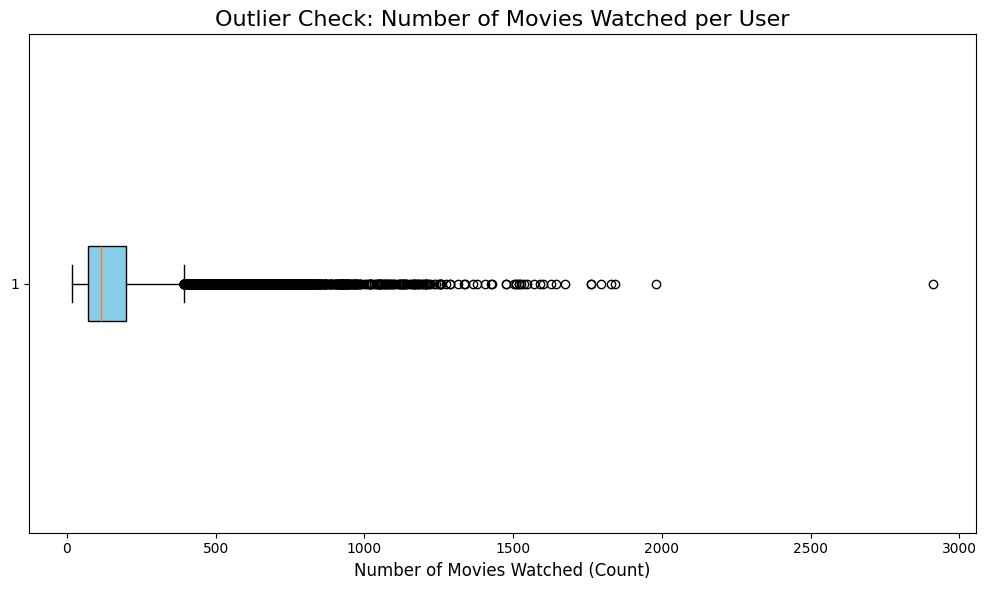

In [6]:
# 사용자별 시청한 영화 개수 계산
user_counts = train['user'].value_counts()

plt.figure(figsize=(10, 6))

plt.boxplot(user_counts.values, vert=False, patch_artist=True, 
            boxprops=dict(facecolor='skyblue'))

plt.title("Outlier Check: Number of Movies Watched per User", fontsize=16)
plt.xlabel("Number of Movies Watched (Count)", fontsize=12)

plt.tight_layout()
plt.show()

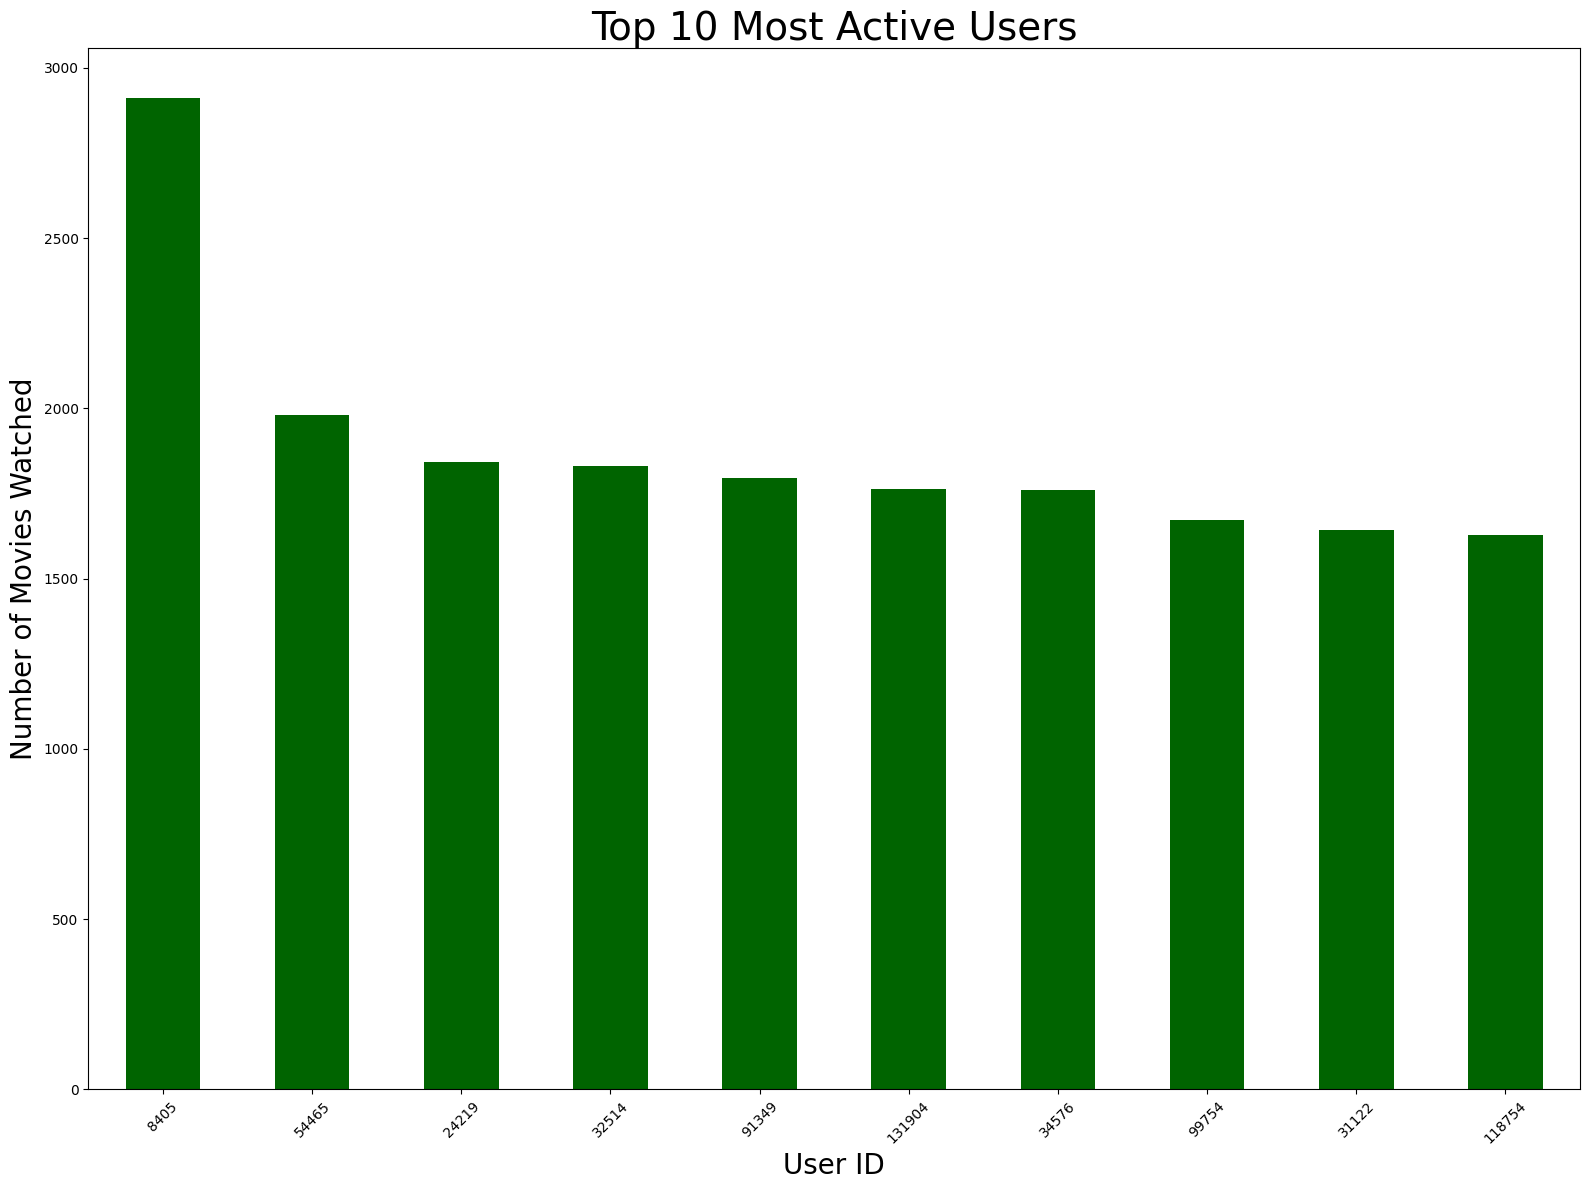

In [9]:
# 사용자별 시청한 영화 개수 분포 (상위 10명 사용자)
top_n = 10
top_user = user_counts.head(top_n)

plt.figure(figsize=(16, 12))

top_user.plot(kind='bar', color='darkgreen')
plt.title(f"Top {top_n} Most Active Users", fontsize=28)
plt.xlabel("User ID", fontsize=20)
plt.ylabel("Number of Movies Watched", fontsize=20)

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

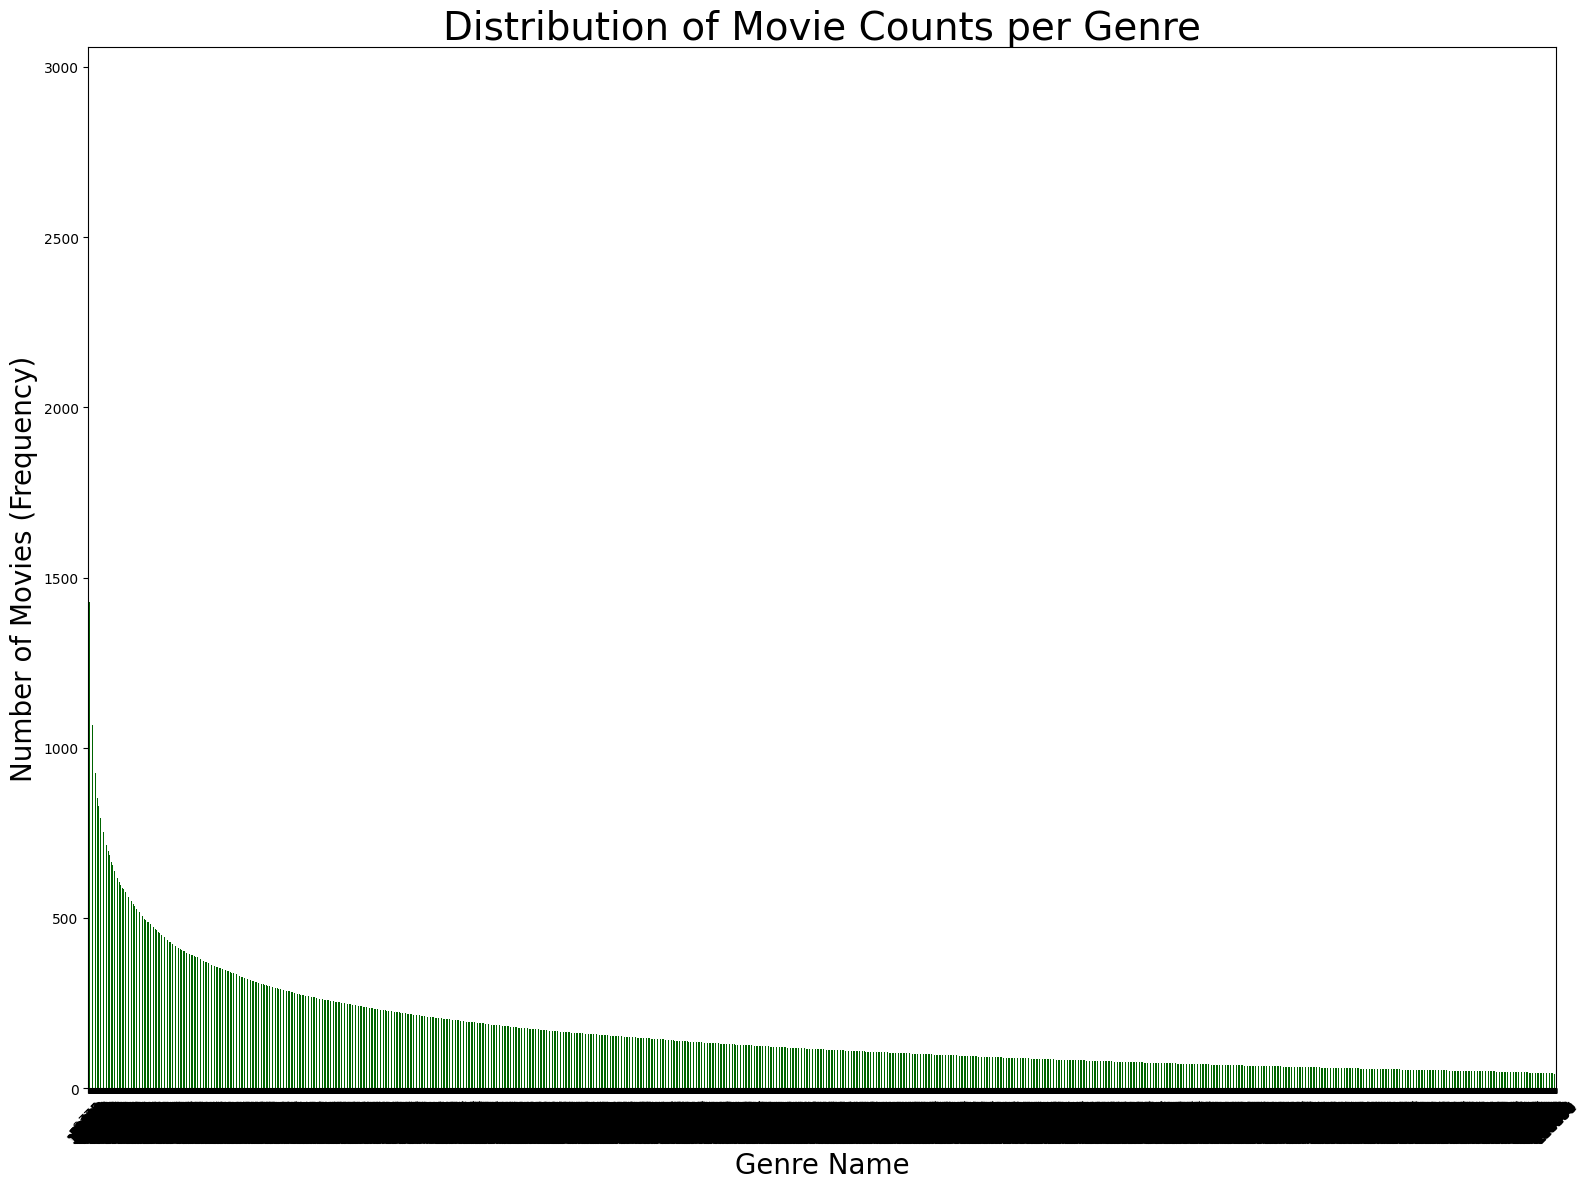

In [10]:
# 사용자별 시청한 영화 개수 분포 (전체)
plt.figure(figsize=(16, 12))

user_counts.plot(kind='bar', color='darkgreen')
plt.title("Distribution of Movie Watch Counts per User", fontsize=28)
plt.xlabel("User ID", fontsize=20)
plt.ylabel("Number of Movies Watched (Frequency)", fontsize=20)

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

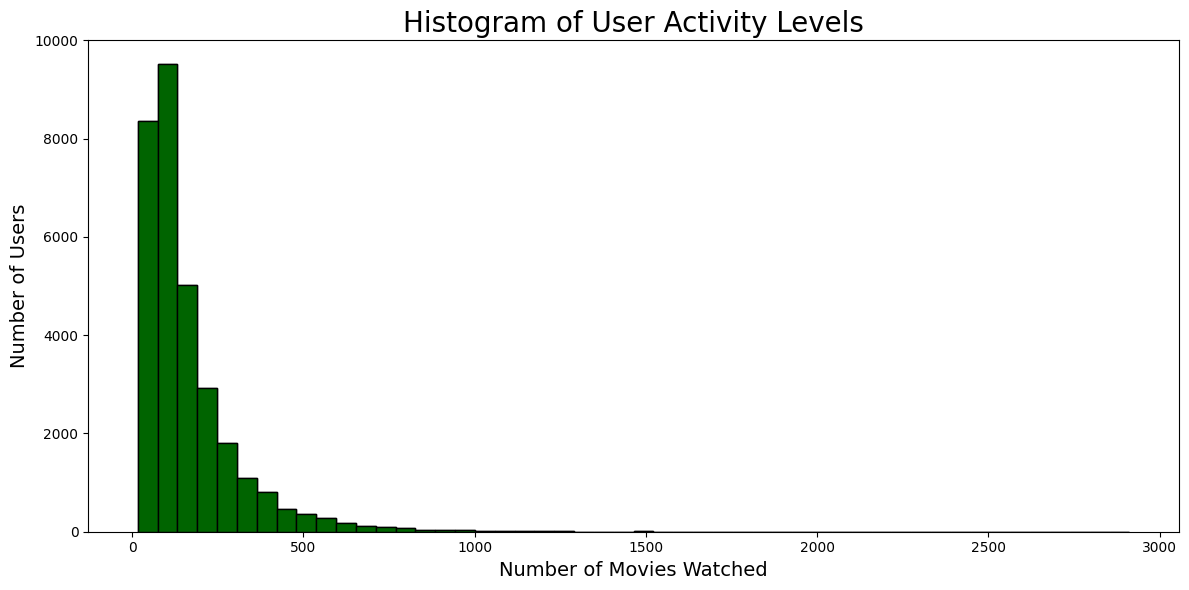

In [ ]:
# 사용자별 시청한 영화 개수 분포 (전체)
# 위 bar 그래프가 계산 때 오래 걸리면 이 셀로 hist 사용
plt.figure(figsize=(12, 6))

user_counts.plot(kind='hist', bins=50, color='darkgreen', edgecolor='black')
plt.title("Histogram of User Activity Levels", fontsize=20)
plt.xlabel("Number of Movies Watched", fontsize=14)
plt.ylabel("Number of Users", fontsize=14)

plt.tight_layout()
plt.show()

/tmp/ipykernel_107861/2145934994.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=total.sort_values('year_month'), x='year_month', palette='viridis')


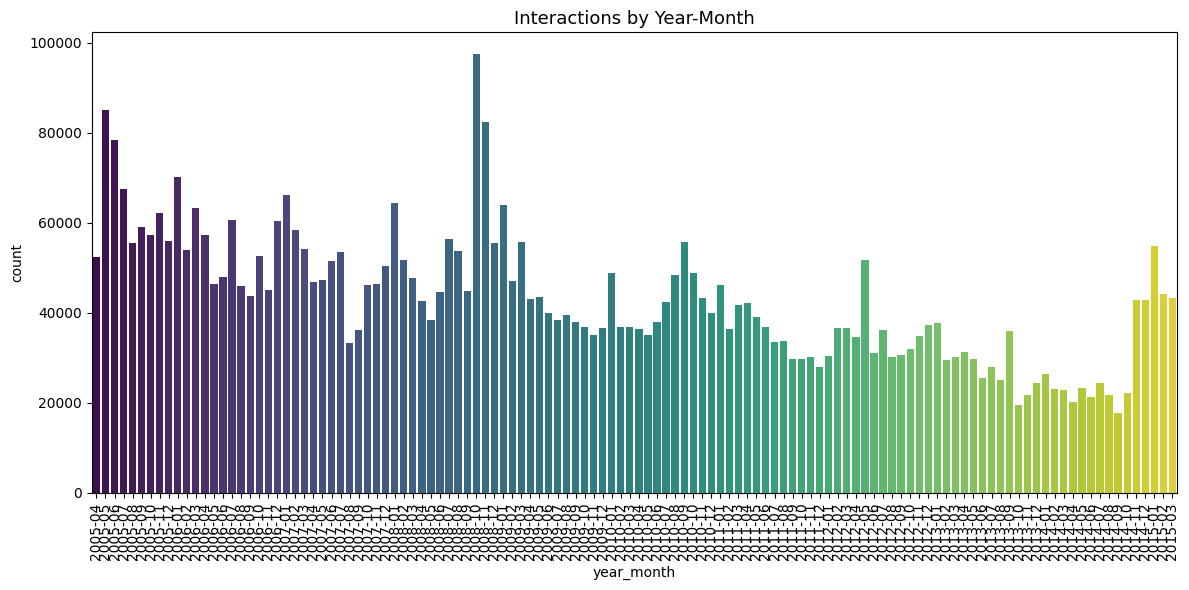

In [40]:
# 시계열 데이터로 변환
total['datetime'] = pd.to_datetime(total['time'], unit='s')

# 분석을 위한 파생 변수 생성
total['year_month'] = total['datetime'].dt.to_period('M').astype(str) # 연-월
total['hour'] = total['datetime'].dt.hour                             # 시간 (0-23)
total['day_of_week'] = total['datetime'].dt.day_name()                # 요일

plt.figure(figsize=(12, 6))

# 연도/월별 시청 기록 수 (데이터의 전체 기간 파악)
sns.countplot(data=total.sort_values('year_month'), x='year_month', palette='viridis')
plt.title("Interactions by Year-Month", fontsize=13)
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

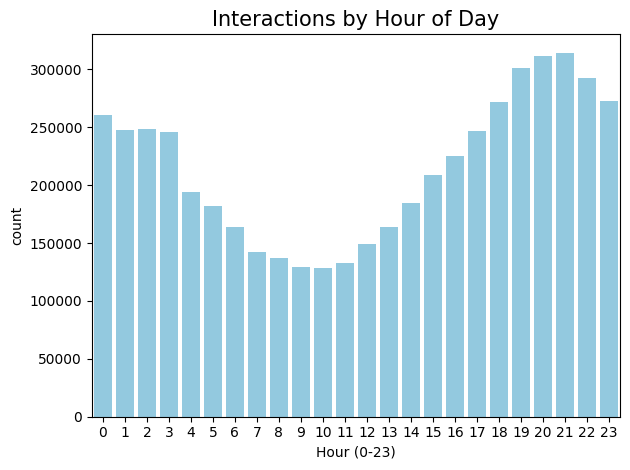

In [ ]:
# 시간대별 시청 분포 (피크 타임 확인)
sns.countplot(data=total, x='hour', color='skyblue')
plt.title("Interactions by Hour of Day", fontsize=15)
plt.xlabel("Hour (0-23)")

plt.tight_layout()
plt.show()

/tmp/ipykernel_107861/3910430539.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=total, x='day_of_week', order=day_order, palette='magma')


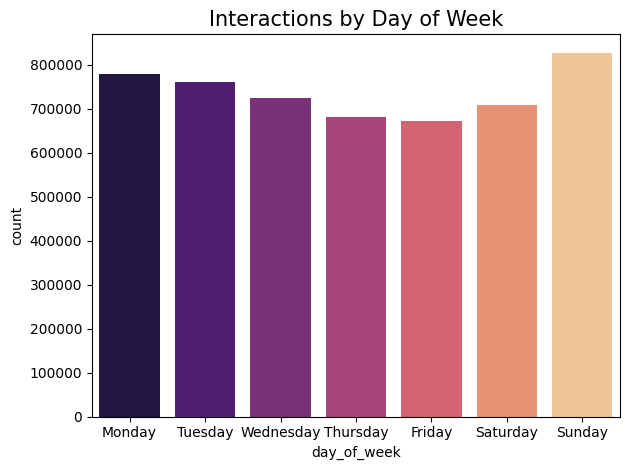

In [ ]:
# 요일별 시청 분포 (주말 vs 평일)
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
sns.countplot(data=total, x='day_of_week', order=day_order, palette='magma')
plt.title("Interactions by Day of Week", fontsize=15)

plt.tight_layout()
plt.show()

In [12]:
# 기본적인 통계치 확인
print("--- 사용자별 영화 개수 통계 ---")

top_user = user_counts.index[0]
max_movies_count = user_counts.iloc[0]
print(f'\n가장 많은 영화를 본 사용자: {top_user}')
print(f'영화 개수: {max_movies_count}')

bot_user = user_counts.index[-1]
min_movies_count = user_counts.iloc[-1]
print(f'\n가장 적은 영화를 본 사용자: {bot_user}')
print(f'영화 개수: {min_movies_count}')

avg_movies_count = user_counts.mean()
median_movies_count = user_counts.median()
std_movies_count = user_counts.std()

print(f'\n사용자별 평균 시청 영화 개수: {avg_movies_count:.2f}개')
print(f'중앙값 (Median) 영화 개수: {median_movies_count:.0f}개')
print(f'사용자별 시청 영화 개수의 표준편차: {std_movies_count:.2f}')

--- 사용자별 영화 개수 통계 ---

가장 많은 영화를 본 사용자: 8405
영화 개수: 2912

가장 적은 영화를 본 사용자: 53188
영화 개수: 16

사용자별 평균 시청 영화 개수: 164.36개
중앙값 (Median) 영화 개수: 114개
사용자별 시청 영화 개수의 표준편차: 150.01


## 🔗 Merge 데이터 분석

In [15]:
# 결측치 확인
total_user_missing_count = total['user'].isnull().sum()
total_item_missing_count = total['item'].isnull().sum()
total_time_missing_count = total['time'].isnull().sum()
total_director_missing_count = total['director'].isnull().sum()
total_writer_missing_count = total['writer'].isnull().sum()
total_title_missing_count = total['title'].isnull().sum()
total_year_missing_count = total['year'].isnull().sum()
total_genre_missing_count = total['genre'].isnull().sum()

print(f'Total 데이터의 user 컬럼 결측치 개수: {total_user_missing_count}')
print(f'Total 데이터의 item 컬럼 결측치 개수: {total_item_missing_count}')
print(f'Total 데이터의 time 컬럼 결측치 개수: {total_time_missing_count}')
print(f'Total 데이터의 director 컬럼 결측치 개수: {total_director_missing_count}')
print(f'Total 데이터의 writer 컬럼 결측치 개수: {total_writer_missing_count}')
print(f'Total 데이터의 title 컬럼 결측치 개수: {total_title_missing_count}')
print(f'Total 데이터의 year 컬럼 결측치 개수: {total_year_missing_count}')
print(f'Total 데이터의 genre 컬럼 결측치 개수: {total_genre_missing_count}')

Total 데이터의 user 컬럼 결측치 개수: 0
Total 데이터의 item 컬럼 결측치 개수: 0
Total 데이터의 time 컬럼 결측치 개수: 0
Total 데이터의 director 컬럼 결측치 개수: 301445
Total 데이터의 writer 컬럼 결측치 개수: 312692
Total 데이터의 title 컬럼 결측치 개수: 0
Total 데이터의 year 컬럼 결측치 개수: 1832
Total 데이터의 genre 컬럼 결측치 개수: 0


--- Column Missing Data Ratios (%) ---
writer      6.066423
director    5.848224
year        0.035542
dtype: float64
----------------------------------------


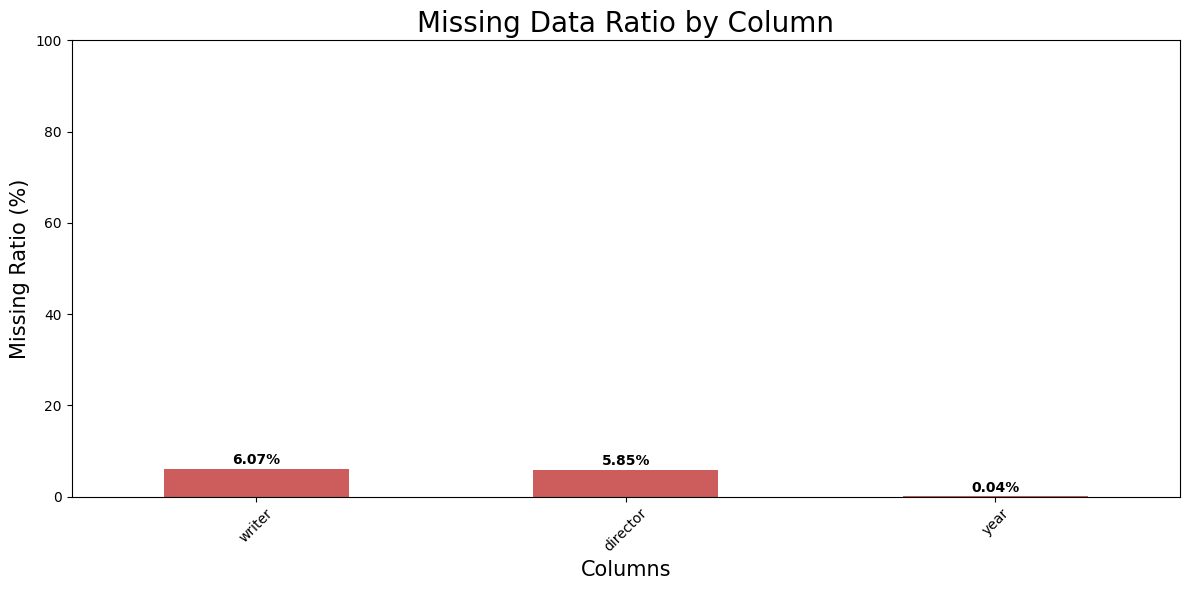

In [19]:
# 전체 행 개수 파악
total_rows = len(total)

# 결측치 비율 계산 (백분율)
missing_ratios = (total.isnull().sum() / total_rows) * 100

# 결측치가 있는 컬럼들만 필터링 (비율이 0보다 큰 경우)
missing_only = missing_ratios[missing_ratios > 0].sort_values(ascending=False)

# 결과 출력
print("--- Column Missing Data Ratios (%) ---")
print(missing_only)
print("-" * 40)

# 결측치 비율 시각화
plt.figure(figsize=(12, 6))
missing_only.plot(kind='bar', color='indianred')

plt.title("Missing Data Ratio by Column", fontsize=20)
plt.ylabel("Missing Ratio (%)", fontsize=15)
plt.xlabel("Columns", fontsize=15)
plt.ylim(0, 100) # 비율이므로 0~100으로 설정

for i, v in enumerate(missing_only):
    plt.text(i, v + 1, f"{v:.2f}%", ha='center', fontweight='bold')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

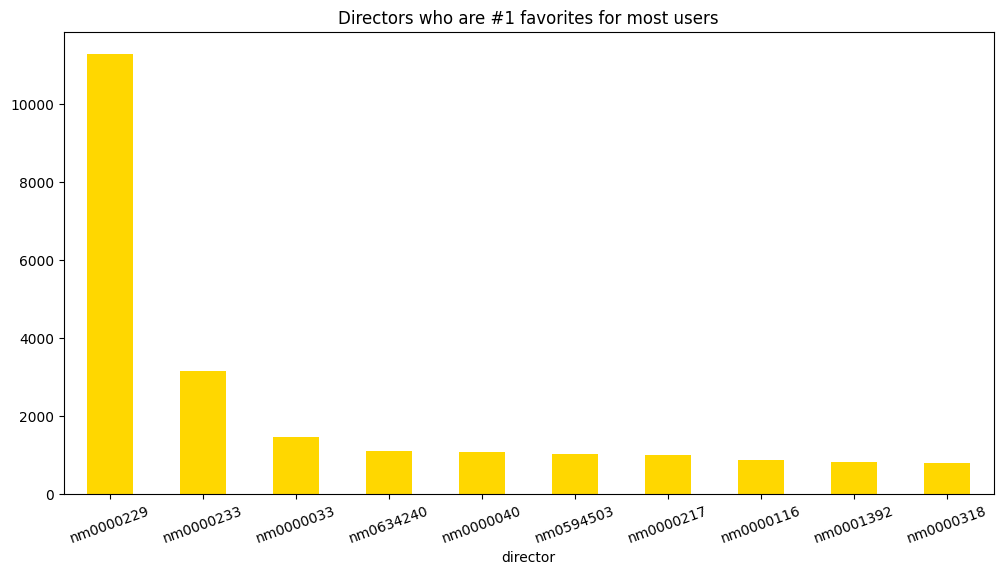

In [32]:
# 감독 데이터가 리스트이므로 explode를 사용하여 유저-감독 1:1 관계로 만듦
user_director_df = total.explode('director')

# 유저별로 각 감독의 영화를 몇 번 봤는지 카운트합니다.
user_director_cnt = user_director_df.groupby(['user', 'director']).size().reset_index(name='count')

# 유저별로 시청 횟수(count)가 높은 순서대로 정렬합니다.
user_director_cnt = user_director_cnt.sort_values(by=['user', 'count'], ascending=[True, False])

# 각 유저별 상위 3명의 감독만 뽑아봅니다.
top_directors_per_user = user_director_cnt.groupby('user').head(1)

# 유저별 TOP 1 감독으로 가장 많이 지목된 감독들
top1_summary = top_directors_per_user['director'].value_counts().head(10)

plt.figure(figsize=(12,6))
top1_summary.plot(kind='bar', color='gold')
plt.title("Directors who are #1 favorites for most users")
plt.xticks(rotation=20)

plt.show()

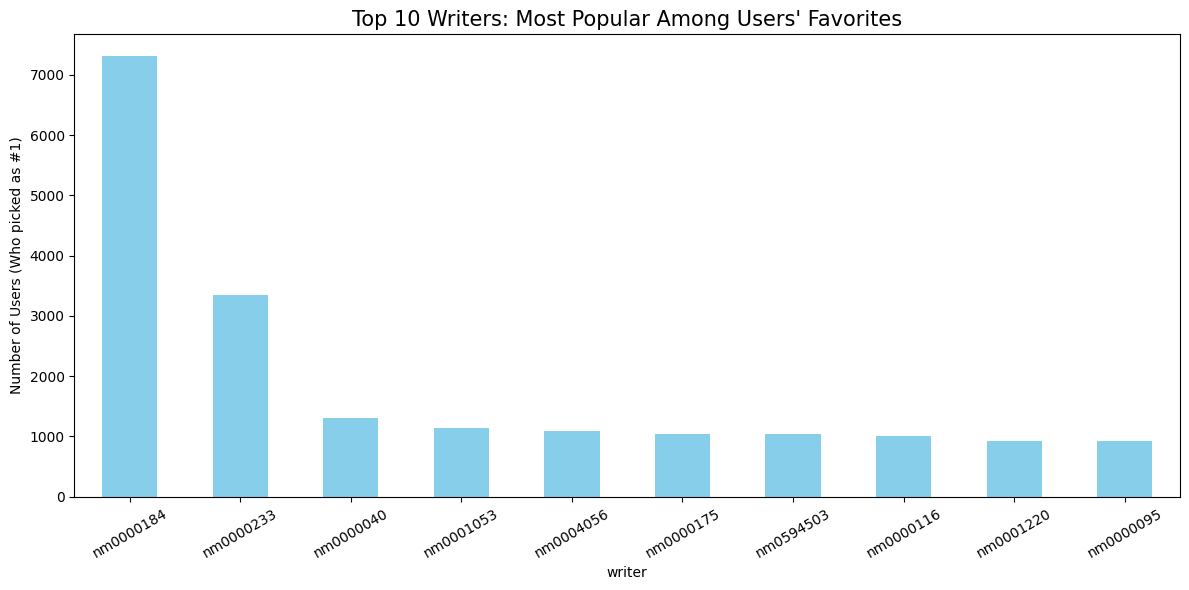

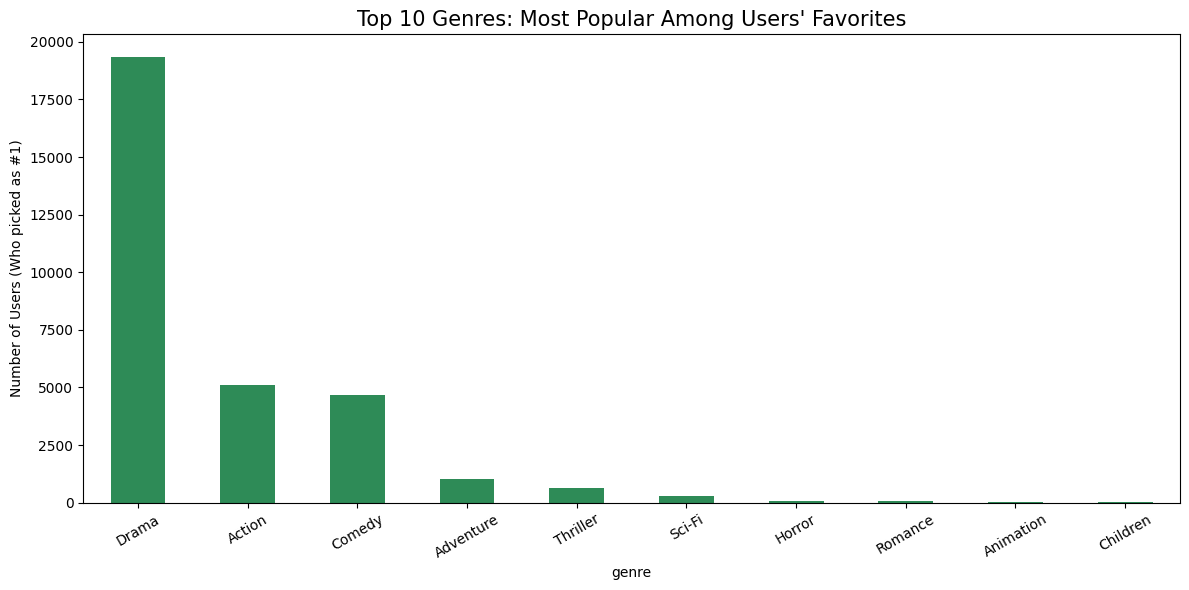

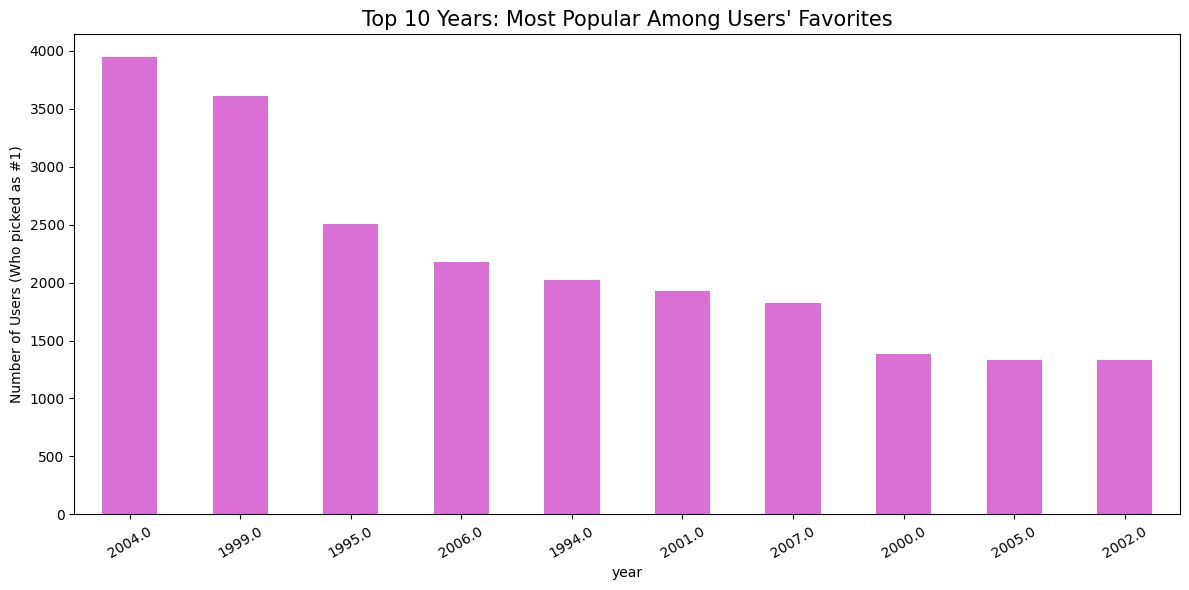

In [33]:
target_cols = ['writer', 'genre', 'year']
colors = ['skyblue', 'seagreen', 'orchid']

for col, color in zip(target_cols, colors):
    # 1. 데이터 준비 (리스트 형태인 writer, genre만 explode 적용)
    if col in ['writer', 'genre']:
        temp_df = total.explode(col)
    else:
        temp_df = total.copy()
    
    # 2. 유저별 해당 컬럼의 빈도 계산
    user_cnt = temp_df.groupby(['user', col]).size().reset_index(name='count')
    
    # 3. 유저별 내림차순 정렬
    user_cnt = user_cnt.sort_values(by=['user', 'count'], ascending=[True, False])
    
    # 4. 각 유저별 최애(1위) 데이터만 추출
    top1_per_user = user_cnt.groupby('user').head(1)
    
    # 5. 최애로 가장 많이 지목된 상위 10개 추출
    top1_summary = top1_per_user[col].value_counts().head(10)
    
    # 6. 시각화
    plt.figure(figsize=(12, 6))
    top1_summary.plot(kind='bar', color=color)
    plt.title(f"Top 10 {col.capitalize()}s: Most Popular Among Users' Favorites", fontsize=15)
    plt.ylabel("Number of Users (Who picked as #1)")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()